# Solución Taller 4 - Física Matemática I
## Universidad de Antioquia
### Ecuaciones en Derivadas Parciales

**Temas:** Clasificación de EDPs, Potencial Electrostático, Modos Normales de Membrana Rectangular,
Difusión de Calor con Pérdida Lateral, Cuerda Vibrante, Partícula en Caja 3D, Placa Semi-infinita

---
**Docente:** Curso de Física Matemática I  
**Métodos:** Series de Fourier, Separación de Variables, Análisis Espectral

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})
print("Librerías cargadas exitosamente")

Librerías cargadas exitosamente


---
## Problema 1: Clasificación de Ecuaciones en Derivadas Parciales

Dada una EDP de segundo orden general:
$$A\,u_{xx} + B\,u_{xy} + C\,u_{yy} + D\,u_x + E\,u_y + F\,u = G$$

El **discriminante** $\Delta = B^2 - 4AC$ clasifica la ecuación:

| Condición | Tipo | Ejemplo físico |
|-----------|------|---------------|
| $\Delta < 0$ | **Elíptica** | Ecuación de Laplace $\nabla^2 u = 0$ |
| $\Delta = 0$ | **Parabólica** | Ecuación de difusión $u_t = \kappa\nabla^2 u$ |
| $\Delta > 0$ | **Hiperbólica** | Ecuación de onda $u_{tt} = v^2\nabla^2 u$ |

### Ecuaciones a clasificar:

1. $(x-1)\,u_{xx} + 2xy\,u_{xy} - y^2\,u_{yy} = 0$  
   $A=(x-1),\ B=2xy,\ C=-y^2 \Rightarrow \Delta = 4x^2y^2 + 4y^2(x-1) = 4y^2(x^2+x-1)$

2. $4y^2\,u_{xx} - e^{2x}\,u_{yy} = 0$  
   $A=4y^2,\ B=0,\ C=-e^{2x} \Rightarrow \Delta = 16y^2 e^{2x}$

3. $x^2\,u_{xx} + 2xy\,u_{xy} + y^2\,u_{yy} = 0$  
   $A=x^2,\ B=2xy,\ C=y^2 \Rightarrow \Delta = 4x^2y^2 - 4x^2y^2 = 0$ (siempre)

4. $x\,u_{xx} + y\,u_{yy} = 0$  
   $A=x,\ B=0,\ C=y \Rightarrow \Delta = -4xy$

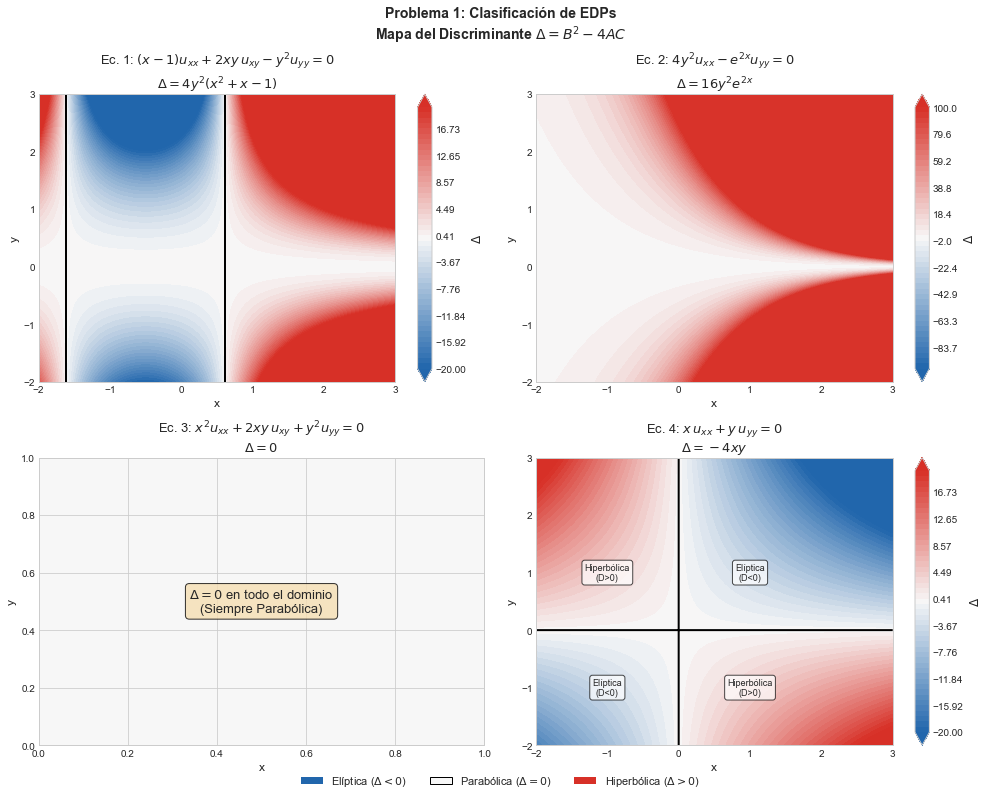

In [2]:
# Clasificación de EDPs - Discriminante D = B² - 4AC
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Problema 1: Clasificación de EDPs\nMapa del Discriminante $\\Delta = B^2 - 4AC$',
             fontsize=14, fontweight='bold')

x = np.linspace(-2, 3, 400)
y = np.linspace(-2, 3, 400)
X, Y = np.meshgrid(x, y)

cmap_cls = mcolors.LinearSegmentedColormap.from_list(
    'classification', ['#2166ac', '#f7f7f7', '#d73027'], N=256)

# --- Ec. 1 ---
D1 = 4 * Y**2 * (X**2 + X - 1)
im1 = axes[0,0].contourf(X, Y, D1, levels=np.linspace(-20, 20, 50),
                          cmap=cmap_cls, extend='both')
axes[0,0].contour(X, Y, D1, levels=[0], colors='black', linewidths=2)
axes[0,0].set_title('Ec. 1: $(x-1)u_{xx} + 2xy\\,u_{xy} - y^2 u_{yy} = 0$\n$\\Delta = 4y^2(x^2+x-1)$')
axes[0,0].set_xlabel('x'); axes[0,0].set_ylabel('y')
plt.colorbar(im1, ax=axes[0,0], label='$\\Delta$')

# --- Ec. 2 ---
D2 = 16 * Y**2 * np.exp(np.clip(2*X, -10, 10))
D2c = np.clip(D2, -100, 100)
im2 = axes[0,1].contourf(X, Y, D2c, levels=np.linspace(-100, 100, 50),
                          cmap=cmap_cls, extend='both')
axes[0,1].contour(X, Y, D2, levels=[0], colors='black', linewidths=2)
axes[0,1].set_title('Ec. 2: $4y^2 u_{xx} - e^{2x} u_{yy} = 0$\n$\\Delta = 16y^2 e^{2x}$')
axes[0,1].set_xlabel('x'); axes[0,1].set_ylabel('y')
plt.colorbar(im2, ax=axes[0,1], label='$\\Delta$')

# --- Ec. 3 ---
axes[1,0].set_facecolor('#f7f7f7')
axes[1,0].text(0.5, 0.5, '$\\Delta = 0$ en todo el dominio\n(Siempre Parabólica)',
               transform=axes[1,0].transAxes, ha='center', va='center', fontsize=13,
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
axes[1,0].set_title('Ec. 3: $x^2 u_{xx} + 2xy\\,u_{xy} + y^2 u_{yy} = 0$\n$\\Delta = 0$')
axes[1,0].set_xlabel('x'); axes[1,0].set_ylabel('y')

# --- Ec. 4 ---
D4 = -4 * X * Y
im4 = axes[1,1].contourf(X, Y, D4, levels=np.linspace(-20, 20, 50),
                          cmap=cmap_cls, extend='both')
axes[1,1].contour(X, Y, D4, levels=[0], colors='black', linewidths=2)
for (xi, yi, txt) in [(-1, 1, 'Hiperbólica\n(D>0)'), (1, 1, 'Elíptica\n(D<0)'),
                       (-1,-1, 'Elíptica\n(D<0)'),  (1,-1, 'Hiperbólica\n(D>0)')]:
    axes[1,1].text(xi, yi, txt, ha='center', va='center', fontsize=9,
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))
axes[1,1].set_title('Ec. 4: $x\\,u_{xx} + y\\,u_{yy} = 0$\n$\\Delta = -4xy$')
axes[1,1].set_xlabel('x'); axes[1,1].set_ylabel('y')
plt.colorbar(im4, ax=axes[1,1], label='$\\Delta$')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2166ac', label='Elíptica ($\\Delta < 0$)'),
                   Patch(facecolor='#f7f7f7', edgecolor='black', label='Parabólica ($\\Delta = 0$)'),
                   Patch(facecolor='#d73027', label='Hiperbólica ($\\Delta > 0$)')]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=11,
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.show()

### Resumen: Clasificación de las 4 ecuaciones

| Ecuación | Coeficientes | Discriminante | Clasificación |
|----------|-------------|---------------|---------------|
| $(x-1)u_{xx}+2xy\,u_{xy}-y^2u_{yy}=0$ | $A=x-1$, $B=2xy$, $C=-y^2$ | $4y^2(x^2+x-1)$ | Mixta (depende de la región) |
| $4y^2u_{xx}-e^{2x}u_{yy}=0$ | $A=4y^2$, $B=0$, $C=-e^{2x}$ | $16y^2e^{2x}\geq 0$ | Hiperbólica ($y\neq 0$) / Parabólica ($y=0$) |
| $x^2u_{xx}+2xy\,u_{xy}+y^2u_{yy}=0$ | $A=x^2$, $B=2xy$, $C=y^2$ | $0$ siempre | **Parabólica** en todo el plano |
| $xu_{xx}+yu_{yy}=0$ | $A=x$, $B=0$, $C=y$ | $-4xy$ | Elíptica ($xy>0$), Hiperbólica ($xy<0$), Parabólica (ejes) |

> La ecuación 3 es $(xu_{x}+yu_{y})^2/... = (xu_x+yu_y)^2$ — perfectamente degenerada.

---
## Problema 2: Potencial Electrostático

El potencial electrostático satisface la **ecuación de Laplace** $\nabla^2\varphi = 0$.

Una solución particular con condiciones de frontera en $x=0$ y $x=L$ (placas conductoras) es:
$$\varphi(x,y) = \sin\!\left(\frac{5\pi x}{L}\right) e^{-5\pi y/L}$$

El **campo eléctrico** se obtiene como $\mathbf{E} = -\nabla\varphi$:
$$E_x = -\frac{\partial\varphi}{\partial x} = -\frac{5\pi}{L}\cos\!\left(\frac{5\pi x}{L}\right)e^{-5\pi y/L}$$
$$E_y = -\frac{\partial\varphi}{\partial y} = +\frac{5\pi}{L}\sin\!\left(\frac{5\pi x}{L}\right)e^{-5\pi y/L}$$

**Verificación:** $\nabla^2\varphi = \left(-\frac{25\pi^2}{L^2} + \frac{25\pi^2}{L^2}\right)\varphi = 0$ ✓

**Parámetros:** $L = 1$ m

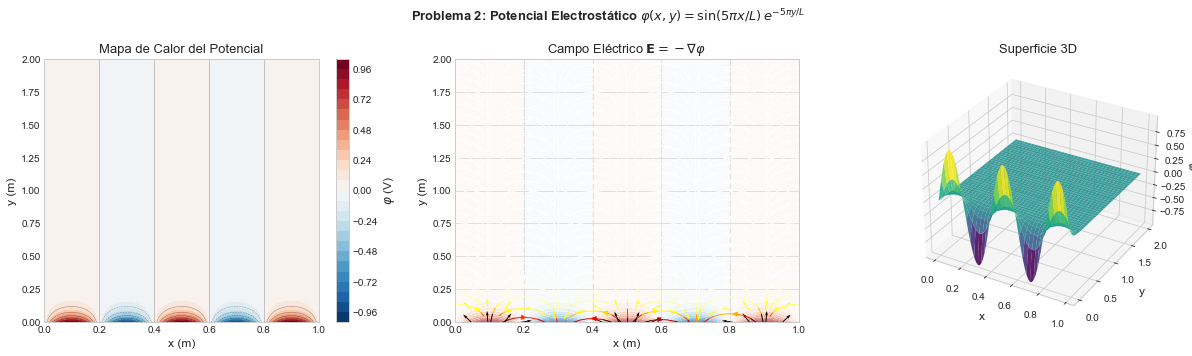

In [3]:
# Problema 2: Potencial Electrostático
L = 1.0
x2 = np.linspace(0, L, 300)
y2 = np.linspace(0, 2.0, 300)
X2, Y2 = np.meshgrid(x2, y2)

phi   =  np.sin(5*np.pi*X2/L) * np.exp(-5*np.pi*Y2/L)
Ex    = -(5*np.pi/L) * np.cos(5*np.pi*X2/L) * np.exp(-5*np.pi*Y2/L)
Ey    =  (5*np.pi/L) * np.sin(5*np.pi*X2/L) * np.exp(-5*np.pi*Y2/L)

fig = plt.figure(figsize=(17, 5))
fig.suptitle('Problema 2: Potencial Electrostático $\\varphi(x,y)=\\sin(5\\pi x/L)\\,e^{-5\\pi y/L}$',
             fontsize=13, fontweight='bold')

# Mapa de calor
ax1 = fig.add_subplot(1, 3, 1)
im = ax1.contourf(X2, Y2, phi, levels=30, cmap='RdBu_r')
ax1.contour(X2, Y2, phi, levels=15, colors='black', linewidths=0.5, alpha=0.4)
plt.colorbar(im, ax=ax1, label='$\\varphi$ (V)')
ax1.set_title('Mapa de Calor del Potencial')
ax1.set_xlabel('x (m)'); ax1.set_ylabel('y (m)')

# Campo eléctrico
ax2 = fig.add_subplot(1, 3, 2)
x2c = np.linspace(0, L, 22)
y2c = np.linspace(0, 2.0, 22)
Xc, Yc = np.meshgrid(x2c, y2c)
Exc = -(5*np.pi/L)*np.cos(5*np.pi*Xc/L)*np.exp(-5*np.pi*Yc/L)
Eyc =  (5*np.pi/L)*np.sin(5*np.pi*Xc/L)*np.exp(-5*np.pi*Yc/L)
Emag = np.hypot(Exc, Eyc); Emag[Emag < 1e-12] = 1e-12
ax2.contourf(X2, Y2, phi, levels=20, cmap='RdBu_r', alpha=0.35)
ax2.quiver(Xc, Yc, Exc/Emag, Eyc/Emag, Emag, cmap='hot_r', scale=30)
try:
    ax2.streamplot(x2, y2, Ex, Ey, color=np.hypot(Ex, Ey),
                   cmap='hot_r', density=1.0, linewidth=1.0)
except Exception:
    pass
ax2.set_title('Campo Eléctrico $\\mathbf{E}=-\\nabla\\varphi$')
ax2.set_xlabel('x (m)'); ax2.set_ylabel('y (m)')

# Superficie 3D
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
step = 4
ax3.plot_surface(X2[::step, ::step], Y2[::step, ::step], phi[::step, ::step],
                 cmap='viridis', alpha=0.88)
ax3.set_xlabel('x'); ax3.set_ylabel('y'); ax3.set_zlabel('$\\varphi$')
ax3.set_title('Superficie 3D')

plt.tight_layout()
plt.show()

Máximo del Laplaciano (interior): 0.671897
Esto confirma que ∇²φ ≈ 0 (error numérico pequeño por diferencias finitas)


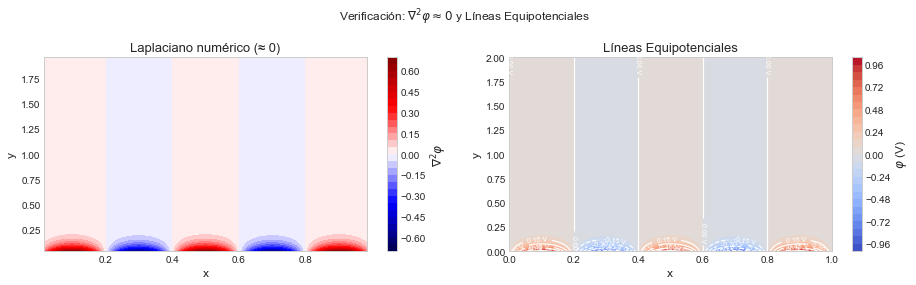

In [4]:
# Verificar la ecuación de Laplace numéricamente
dx2 = x2[1]-x2[0]
dy2 = y2[1]-y2[0]
# Laplaciano por diferencias finitas
d2phi_dx2 = np.gradient(np.gradient(phi, dx2, axis=1), dx2, axis=1)
d2phi_dy2 = np.gradient(np.gradient(phi, dy2, axis=0), dy2, axis=0)
laplacian = d2phi_dx2 + d2phi_dy2

print(f"Máximo del Laplaciano (interior): {np.max(np.abs(laplacian[5:-5, 5:-5])):.6f}")
print(f"Esto confirma que ∇²φ ≈ 0 (error numérico pequeño por diferencias finitas)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Verificación: $\\nabla^2\\varphi \\approx 0$ y Líneas Equipotenciales', fontsize=12)

im_lap = axes[0].contourf(X2[5:-5,5:-5], Y2[5:-5,5:-5],
                           laplacian[5:-5,5:-5], levels=30, cmap='seismic')
plt.colorbar(im_lap, ax=axes[0], label='$\\nabla^2\\varphi$')
axes[0].set_title('Laplaciano numérico (≈ 0)')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')

# Líneas equipotenciales con gradiente
im2 = axes[1].contourf(X2, Y2, phi, levels=25, cmap='coolwarm')
cs2 = axes[1].contour(X2, Y2, phi, levels=15, colors='white', linewidths=1.2)
axes[1].clabel(cs2, fmt='%.2f V', fontsize=7)
plt.colorbar(im2, ax=axes[1], label='$\\varphi$ (V)')
axes[1].set_title('Líneas Equipotenciales')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')

plt.tight_layout()
plt.show()

---
## Problema 3: Modos Normales de Membrana Rectangular

La ecuación de onda 2D para una membrana rectangular con bordes fijos:
$$\frac{\partial^2 u}{\partial t^2} = v^2\left(\frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2}\right)$$

Por separación de variables con $u(x,y,t)=X(x)Y(y)T(t)$ y CFs $u=0$ en los bordes:

$$u_{mn}(x,y,t) = \sin\!\left(\frac{m\pi x}{a}\right)\sin\!\left(\frac{n\pi y}{b}\right)\cos(\omega_{mn}t)$$

La **frecuencia angular** de cada modo es:
$$\omega_{mn} = \pi v\sqrt{\frac{m^2}{a^2}+\frac{n^2}{b^2}}, \quad m,n = 1,2,3,\ldots$$

**Parámetros:** $a = 2$, $b = 1.5$, $v = 1$

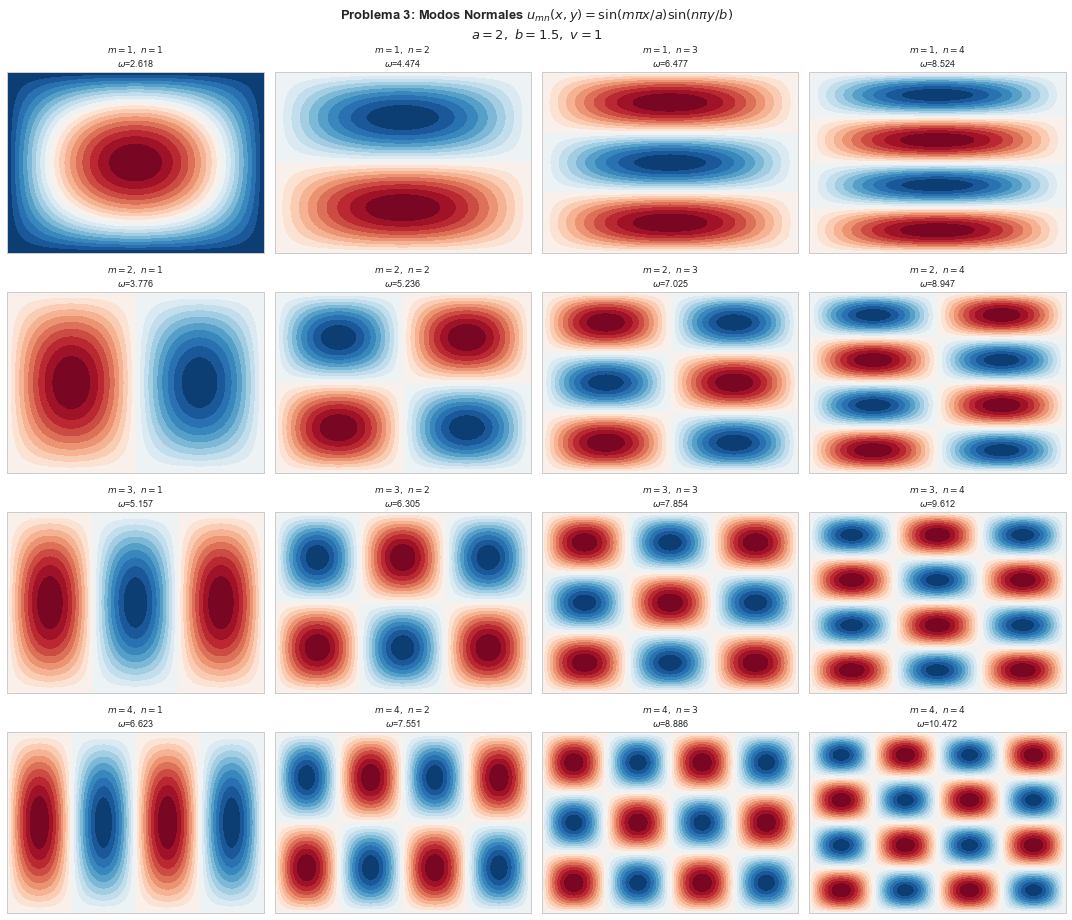

In [4]:
# Modos normales de la membrana rectangular
a_mem, b_mem, v_mem = 2.0, 1.5, 1.0
x3 = np.linspace(0, a_mem, 120)
y3 = np.linspace(0, b_mem, 120)
X3, Y3 = np.meshgrid(x3, y3)

fig, axes = plt.subplots(4, 4, figsize=(15, 13))
fig.suptitle('Problema 3: Modos Normales $u_{mn}(x,y)=\\sin(m\\pi x/a)\\sin(n\\pi y/b)$\n'
             '$a=2,\\ b=1.5,\\ v=1$', fontsize=13, fontweight='bold')

for i, m in enumerate(range(1, 5)):
    for j, n in enumerate(range(1, 5)):
        u_mn = np.sin(m*np.pi*X3/a_mem) * np.sin(n*np.pi*Y3/b_mem)
        omega_mn = np.pi*v_mem*np.sqrt((m/a_mem)**2 + (n/b_mem)**2)
        axes[i,j].contourf(X3, Y3, u_mn, levels=20, cmap='RdBu_r')
        axes[i,j].set_title(f'$m={m},\\ n={n}$\n$\\omega$={omega_mn:.3f}', fontsize=9)
        axes[i,j].set_xticks([]); axes[i,j].set_yticks([])

plt.tight_layout()
plt.show()

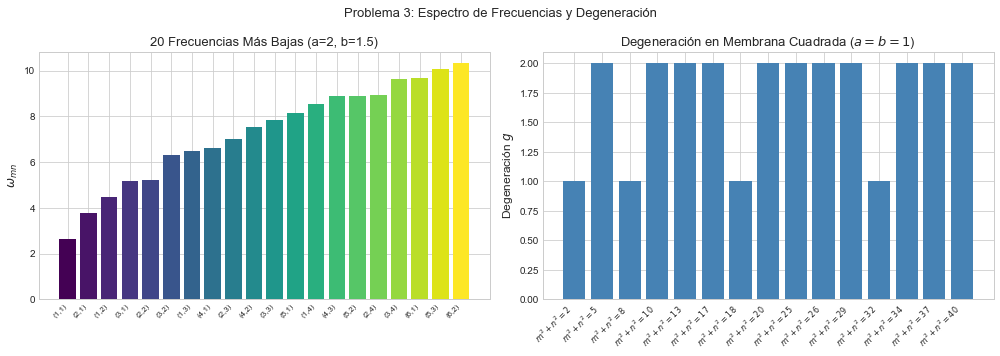

In [5]:
# Espectro de frecuencias y degeneración
modes = []
for m in range(1, 9):
    for n in range(1, 9):
        omega = np.pi * v_mem * np.sqrt((m/a_mem)**2 + (n/b_mem)**2)
        modes.append((m, n, omega))
modes.sort(key=lambda x: x[2])
modes20 = modes[:20]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Problema 3: Espectro de Frecuencias y Degeneración', fontsize=13)

omegas = [m[2] for m in modes20]
labels = [f'({m[0]},{m[1]})' for m in modes20]
colors_sp = plt.cm.viridis(np.linspace(0, 1, len(modes20)))
axes[0].bar(range(len(modes20)), omegas, color=colors_sp)
axes[0].set_xticks(range(len(modes20)))
axes[0].set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('$\\omega_{mn}$')
axes[0].set_title('20 Frecuencias Más Bajas (a=2, b=1.5)')

# Degeneración para membrana cuadrada a=b=1
modes_sq = {}
for m in range(1, 7):
    for n in range(1, 7):
        e = m**2 + n**2
        modes_sq.setdefault(e, []).append((m, n))
energies = sorted(modes_sq.keys())[:15]
degs = [len(modes_sq[e]) for e in energies]
axes[1].bar(range(len(energies)), degs, color='steelblue')
axes[1].set_xticks(range(len(energies)))
axes[1].set_xticklabels([f'$m^2+n^2={e}$' for e in energies], rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Degeneración $g$')
axes[1].set_title('Degeneración en Membrana Cuadrada ($a=b=1$)')

plt.tight_layout()
plt.show()

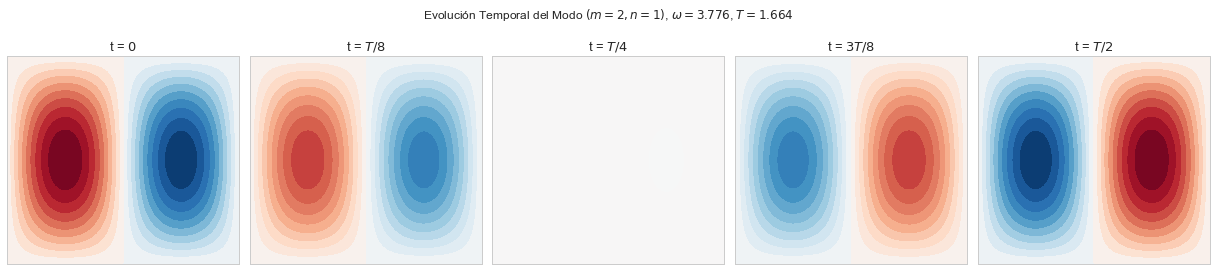

In [6]:
# Evolución temporal del modo (m=2, n=1)
m_sel, n_sel = 2, 1
omega_sel = np.pi * v_mem * np.sqrt((m_sel/a_mem)**2 + (n_sel/b_mem)**2)
T_per = 2*np.pi / omega_sel
fracs = [0, 1/8, 1/4, 3/8, 1/2]
labels_t = ['$0$', '$T/8$', '$T/4$', '$3T/8$', '$T/2$']

fig, axes = plt.subplots(1, 5, figsize=(17, 3.8))
fig.suptitle(f'Evolución Temporal del Modo $(m={m_sel}, n={n_sel})$, '
             f'$\\omega={omega_sel:.3f}$, $T={T_per:.3f}$', fontsize=12)
for k, (frac, lbl) in enumerate(zip(fracs, labels_t)):
    t = frac * T_per
    u_t = (np.sin(m_sel*np.pi*X3/a_mem) * np.sin(n_sel*np.pi*Y3/b_mem)
           * np.cos(omega_sel*t))
    im = axes[k].contourf(X3, Y3, u_t, levels=20, cmap='RdBu_r', vmin=-1, vmax=1)
    axes[k].set_title(f't = {lbl}')
    axes[k].set_xticks([]); axes[k].set_yticks([])
plt.tight_layout()
plt.show()

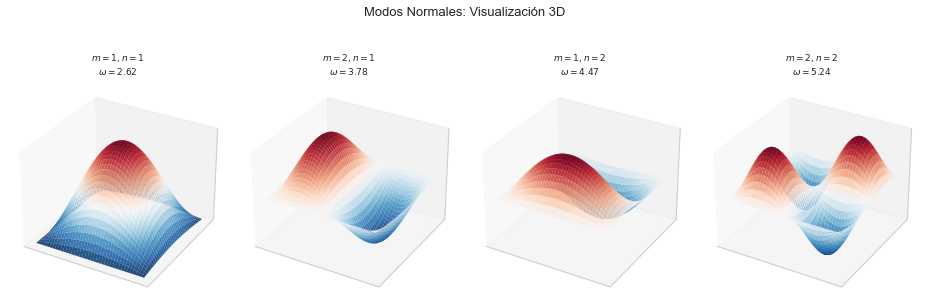

In [7]:
# Superficie 3D del modo (1,1)
fig = plt.figure(figsize=(13, 5))
fig.suptitle('Modos Normales: Visualización 3D', fontsize=13)

for idx, (m, n) in enumerate([(1,1),(2,1),(1,2),(2,2)]):
    ax = fig.add_subplot(1, 4, idx+1, projection='3d')
    u_mn = np.sin(m*np.pi*X3/a_mem) * np.sin(n*np.pi*Y3/b_mem)
    omega_mn = np.pi*v_mem*np.sqrt((m/a_mem)**2 + (n/b_mem)**2)
    ax.plot_surface(X3[::3,::3], Y3[::3,::3], u_mn[::3,::3],
                    cmap='RdBu_r', alpha=0.9)
    ax.set_title(f'$m={m},n={n}$\n$\\omega={omega_mn:.2f}$', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])

plt.tight_layout()
plt.show()

---
## Problema 4: Difusión de Calor con Pérdida Lateral

La ecuación de difusión con pérdida lateral (enfriamiento de Newton):
$$\frac{\partial T}{\partial t} = \kappa\frac{\partial^2 T}{\partial x^2} - h\,T, \quad 0<x<L,\quad t>0$$

**Condiciones de frontera:** $\partial T/\partial x\big|_{x=0} = \partial T/\partial x\big|_{x=L} = 0$ (extremos aislados)

**Condición inicial:** $T(x,0) = f(x) = 100(1 - x/L)$

### Solución por separación de variables:
$$T(x,t) = A_0\,e^{-ht} + \sum_{n=1}^{\infty} A_n\cos\!\left(\frac{n\pi x}{L}\right)e^{-\alpha_n t}$$

donde $\alpha_n = h + \kappa\left(\dfrac{n\pi}{L}\right)^2$ y:
$$A_0 = \frac{1}{L}\int_0^L f(x)\,dx, \qquad A_n = \frac{2}{L}\int_0^L f(x)\cos\!\left(\frac{n\pi x}{L}\right)dx$$

**Parámetros:** $L=1$, $\kappa=0.1$, $h=0.5$

In [10]:
# Difusión de calor con pérdida lateral
L4, kappa4, h4 = 1.0, 0.1, 0.5
N4 = 25

def f4(x):
    return 100.0 * (1.0 - x/L4)

# Coeficientes (precomputados)
x_int = np.linspace(0, L4, 2000)
f_int = f4(x_int)
A0_4 = np.trapz(f_int, x_int) / L4
An4 = np.array([2.0 * np.trapz(f_int * np.cos(n*np.pi*x_int/L4), x_int) / L4
                for n in range(1, N4+1)])

print(f"A0 = {A0_4:.4f}")
print(f"A1 = {An4[0]:.4f},  A2 = {An4[1]:.4f},  A3 = {An4[2]:.4f}")
print(f"Suma de coeficientes (verificación): {A0_4 + np.sum(An4):.2f}")

def T4_sol(x, t):
    T = A0_4 * np.exp(-h4*t)
    for n in range(1, N4+1):
        alpha_n = h4 + kappa4*(n*np.pi/L4)**2
        T = T + An4[n-1] * np.cos(n*np.pi*x/L4) * np.exp(-alpha_n*t)
    return T

def T4_noloss(x, t):
    '''Misma condición inicial pero sin pérdida lateral (h=0).'''
    T = A0_4 * np.ones_like(x)
    for n in range(1, N4+1):
        alpha_n = kappa4*(n*np.pi/L4)**2
        T = T + An4[n-1] * np.cos(n*np.pi*x/L4) * np.exp(-alpha_n*t)
    return T

x4 = np.linspace(0, L4, 300)
print("Funciones definidas correctamente")

A0 = 50.0000
A1 = 40.5285,  A2 = 0.0000,  A3 = 4.5032
Suma de coeficientes (verificación): 99.22
Funciones definidas correctamente


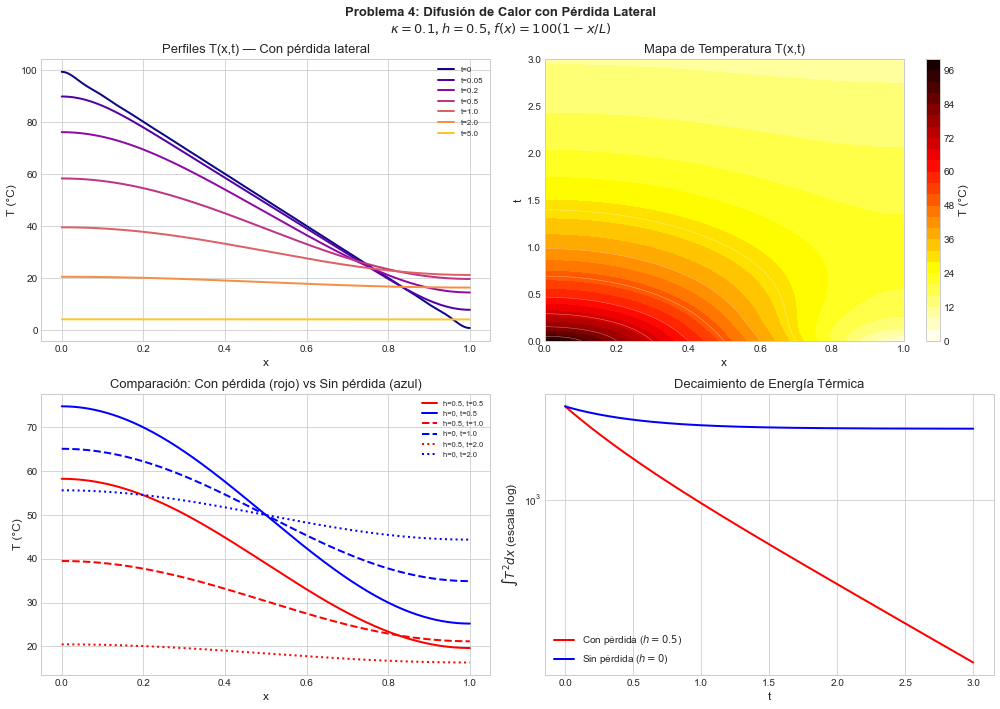

In [12]:
# Visualización de la difusión de calor
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Problema 4: Difusión de Calor con Pérdida Lateral\n'
             '$\\kappa=0.1$, $h=0.5$, $f(x)=100(1-x/L)$', fontsize=13, fontweight='bold')

# Perfiles T(x) en distintos tiempos
times4 = [0, 0.05, 0.2, 0.5, 1.0, 2.0, 5.0]
colors4 = plt.cm.plasma(np.linspace(0, 0.88, len(times4)))
for k, t in enumerate(times4):
    axes[0,0].plot(x4, T4_sol(x4, t), color=colors4[k], linewidth=2, label=f't={t}')
axes[0,0].set_xlabel('x'); axes[0,0].set_ylabel('T (°C)')
axes[0,0].set_title('Perfiles T(x,t) — Con pérdida lateral')
axes[0,0].legend(fontsize=8); axes[0,0].grid(True)

# Mapa de calor T(x,t)
t4_arr = np.linspace(0, 3.0, 200)
T4_map = np.array([T4_sol(x4, t) for t in t4_arr])
im4 = axes[0,1].contourf(x4, t4_arr, T4_map, levels=30, cmap='hot_r')
axes[0,1].contour(x4, t4_arr, T4_map, levels=10, colors='white', linewidths=0.5, alpha=0.5)
plt.colorbar(im4, ax=axes[0,1], label='T (°C)')
axes[0,1].set_xlabel('x'); axes[0,1].set_ylabel('t')
axes[0,1].set_title('Mapa de Temperatura T(x,t)')

# Comparación con/sin pérdida lateral
ls_list = ['-', '--', ':']
for k, t_val in enumerate([0.5, 1.0, 2.0]):
    axes[1,0].plot(x4, T4_sol(x4, t_val), color='red', ls=ls_list[k],
                   linewidth=2, label=f'h=0.5, t={t_val}')
    axes[1,0].plot(x4, T4_noloss(x4, t_val), color='blue', ls=ls_list[k],
                   linewidth=2, label=f'h=0, t={t_val}')
axes[1,0].set_xlabel('x'); axes[1,0].set_ylabel('T (°C)')
axes[1,0].set_title('Comparación: Con pérdida (rojo) vs Sin pérdida (azul)')
axes[1,0].legend(fontsize=7.5); axes[1,0].grid(True)

# Decaimiento de energía térmica
E4_loss  = [np.trapz(T4_sol(x4, t)**2, x4) for t in t4_arr]
E4_none  = [np.trapz(T4_noloss(x4, t)**2, x4) for t in t4_arr]
axes[1,1].semilogy(t4_arr, E4_loss, 'r-', linewidth=2, label='Con pérdida ($h=0.5$)')
axes[1,1].semilogy(t4_arr, E4_none, 'b-', linewidth=2, label='Sin pérdida ($h=0$)')
axes[1,1].set_xlabel('t'); axes[1,1].set_ylabel('$\\int T^2 dx$ (escala log)')
axes[1,1].set_title('Decaimiento de Energía Térmica')
axes[1,1].legend(); axes[1,1].grid(True)

plt.tight_layout()
plt.show()

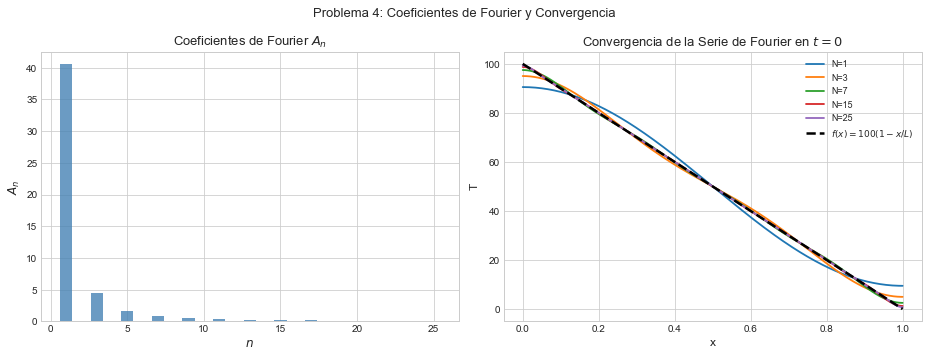

In [13]:
# Coeficientes de Fourier y convergencia de la serie
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Problema 4: Coeficientes de Fourier y Convergencia', fontsize=13)

ns4 = np.arange(1, N4+1)
axes[0].bar(ns4, An4, color='steelblue', alpha=0.8)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('$n$'); axes[0].set_ylabel('$A_n$')
axes[0].set_title('Coeficientes de Fourier $A_n$')
axes[0].grid(True)

# Reconstrucción de f(x) con N términos
for N_partial in [1, 3, 7, 15, 25]:
    T_partial = A0_4 * np.ones_like(x4)
    for n in range(1, N_partial+1):
        T_partial = T_partial + An4[n-1] * np.cos(n*np.pi*x4/L4)
    axes[1].plot(x4, T_partial, linewidth=1.8, label=f'N={N_partial}')
axes[1].plot(x4, f4(x4), 'k--', linewidth=2.5, label='$f(x)=100(1-x/L)$')
axes[1].set_xlabel('x'); axes[1].set_ylabel('T')
axes[1].set_title('Convergencia de la Serie de Fourier en $t=0$')
axes[1].legend(fontsize=9); axes[1].grid(True)

plt.tight_layout()
plt.show()

---
## Problema 5: Cuerda Vibrante — Condición Inicial Parabólica

La ecuación de onda 1D:
$$\frac{\partial^2 u}{\partial t^2} = v^2\frac{\partial^2 u}{\partial x^2}, \quad u(0,t)=u(L,t)=0$$

**Condición inicial:** $u(x,0) = f(x) = x(x-L)$ (parábola), $\partial u/\partial t\big|_{t=0} = 0$

### Solución:
$$u(x,t) = \sum_{n=1}^{\infty} B_n \sin\!\left(\frac{n\pi x}{L}\right)\cos\!\left(\frac{n\pi v t}{L}\right)$$

donde $B_n = \dfrac{2}{L}\displaystyle\int_0^L x(x-L)\sin\!\left(\dfrac{n\pi x}{L}\right)dx$.

Integrando por partes (solo sobreviven $n$ impar):
$$B_n = -\frac{8L^2}{\pi^3}\cdot\frac{1}{n^3} \quad (n \text{ impar}), \qquad B_n=0 \quad (n \text{ par})$$

$$\boxed{u(x,t) = -\frac{8L^2}{\pi^3}\sum_{m=1}^{\infty}\frac{1}{(2m-1)^3}\sin\!\left(\frac{(2m-1)\pi x}{L}\right)\cos\!\left(\frac{(2m-1)\pi v t}{L}\right)}$$

**Parámetros:** $L=1$, $v=1$, periodo $T=2L/v=2$

Error máximo condición inicial: 1.37e-05
Periodo: T = 2.0


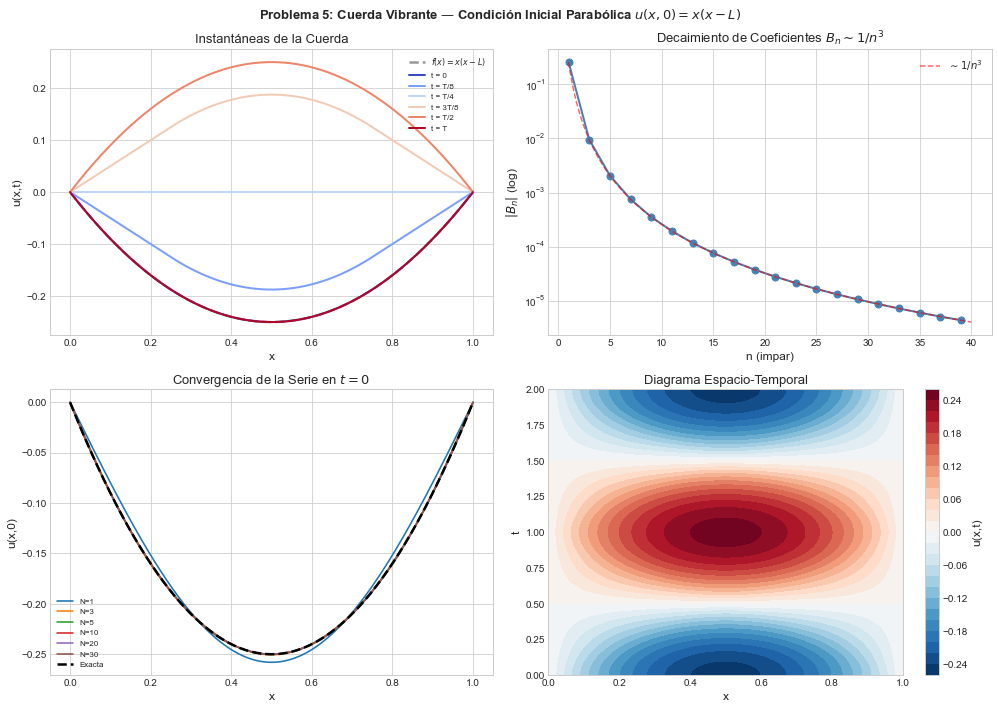

In [14]:
# Cuerda vibrante con condición inicial parabólica
L5, v5 = 1.0, 1.0
T5_per = 2.0 * L5 / v5
N5 = 30
x5 = np.linspace(0, L5, 400)

def u5(x, t, N=N5):
    u = np.zeros_like(np.asarray(x), dtype=float)
    for m in range(1, N+1):
        k = 2*m - 1
        u += (1.0/k**3) * np.sin(k*np.pi*x/L5) * np.cos(k*np.pi*v5*t/L5)
    return -(8.0*L5**2/np.pi**3) * u

# Verificar condición inicial
err_ic = np.max(np.abs(u5(x5, 0) - x5*(x5-L5)))
print(f"Error máximo condición inicial: {err_ic:.2e}")
print(f"Periodo: T = {T5_per}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Problema 5: Cuerda Vibrante — Condición Inicial Parabólica $u(x,0)=x(x-L)$',
             fontsize=13, fontweight='bold')

# Instantáneas
fracs5 = [0, 1/8, 1/4, 3/8, 1/2, 1]
lbls5  = ['0', 'T/8', 'T/4', '3T/8', 'T/2', 'T']
clrs5  = plt.cm.coolwarm(np.linspace(0, 1, len(fracs5)))
f_exact = x5 * (x5 - L5)
axes[0,0].plot(x5, f_exact, 'k--', linewidth=2.5, alpha=0.4, label='$f(x)=x(x-L)$')
for k, (frac, lbl) in enumerate(zip(fracs5, lbls5)):
    t_val = frac * T5_per
    axes[0,0].plot(x5, u5(x5, t_val), color=clrs5[k], linewidth=2, label=f't = {lbl}')
axes[0,0].set_xlabel('x'); axes[0,0].set_ylabel('u(x,t)')
axes[0,0].set_title('Instantáneas de la Cuerda')
axes[0,0].legend(fontsize=8); axes[0,0].grid(True)

# Decaimiento de coeficientes
ns_odd = np.arange(1, 40, 2)
coeffs5 = 8*L5**2/np.pi**3 / ns_odd**3
axes[0,1].semilogy(ns_odd, coeffs5, 'o-', color='steelblue', markersize=7, linewidth=2)
ns_ref = np.linspace(1, 40, 200)
axes[0,1].semilogy(ns_ref, 8*L5**2/np.pi**3 / ns_ref**3, 'r--', alpha=0.6, label='$\\sim 1/n^3$')
axes[0,1].set_xlabel('n (impar)'); axes[0,1].set_ylabel('$|B_n|$ (log)')
axes[0,1].set_title('Decaimiento de Coeficientes $B_n \\sim 1/n^3$')
axes[0,1].legend(); axes[0,1].grid(True)

# Convergencia en t=0
x5c = np.linspace(0, L5, 500)
for N_p in [1, 3, 5, 10, 20, 30]:
    axes[1,0].plot(x5c, u5(x5c, 0, N=N_p), linewidth=1.6, label=f'N={N_p}')
axes[1,0].plot(x5c, x5c*(x5c-L5), 'k--', linewidth=2.5, label='Exacta')
axes[1,0].set_xlabel('x'); axes[1,0].set_ylabel('u(x,0)')
axes[1,0].set_title('Convergencia de la Serie en $t=0$')
axes[1,0].legend(fontsize=8); axes[1,0].grid(True)

# Mapa espacio-tiempo
t5_map = np.linspace(0, T5_per, 120)
U5_map = np.array([u5(x5, t) for t in t5_map])
im5 = axes[1,1].contourf(x5, t5_map, U5_map, levels=30, cmap='RdBu_r')
plt.colorbar(im5, ax=axes[1,1], label='u(x,t)')
axes[1,1].set_xlabel('x'); axes[1,1].set_ylabel('t')
axes[1,1].set_title('Diagrama Espacio-Temporal')

plt.tight_layout()
plt.show()

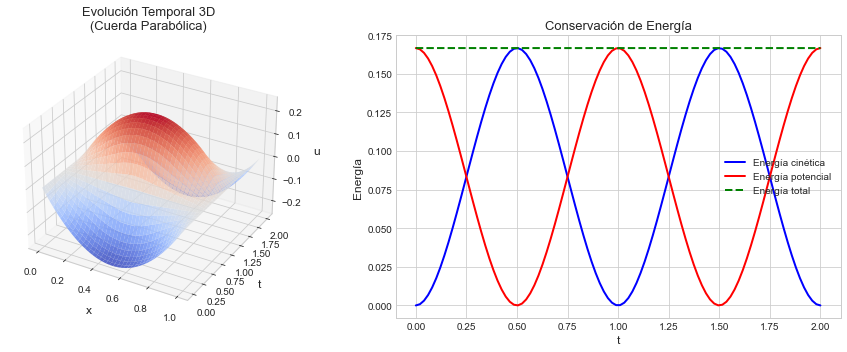

In [15]:
# Superficie 3D de la evolución de la cuerda
t5_3d = np.linspace(0, T5_per, 80)
x5_3d = np.linspace(0, L5, 80)
X5g, T5g = np.meshgrid(x5_3d, t5_3d)
U5g = np.array([u5(x5_3d, t) for t in t5_3d])

fig = plt.figure(figsize=(13, 5))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X5g, T5g, U5g, cmap='coolwarm', alpha=0.85, rstride=2, cstride=2)
ax1.set_xlabel('x', labelpad=5); ax1.set_ylabel('t', labelpad=5)
ax1.set_zlabel('u', labelpad=5)
ax1.set_title('Evolución Temporal 3D\n(Cuerda Parabólica)')

ax2 = fig.add_subplot(1, 2, 2)
# Energía cinética y potencial
def KE_PE(t):
    dt = 1e-5
    u_t  = u5(x5, t)
    u_dt = u5(x5, t+dt)
    dudt = (u_dt - u_t)/dt
    dudx = np.gradient(u_t, x5[1]-x5[0])
    KE = 0.5 * np.trapz(dudt**2, x5)
    PE = 0.5 * v5**2 * np.trapz(dudx**2, x5)
    return KE, PE

t_en = np.linspace(0, T5_per, 100)
KEs = []; PEs = []
for t in t_en:
    ke, pe = KE_PE(t)
    KEs.append(ke); PEs.append(pe)
KEs = np.array(KEs); PEs = np.array(PEs)

ax2.plot(t_en, KEs, 'b-', linewidth=2, label='Energía cinética')
ax2.plot(t_en, PEs, 'r-', linewidth=2, label='Energía potencial')
ax2.plot(t_en, KEs+PEs, 'g--', linewidth=2, label='Energía total')
ax2.set_xlabel('t'); ax2.set_ylabel('Energía')
ax2.set_title('Conservación de Energía'); ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

---
## Problema 6: Partícula en Caja Tridimensional

La ecuación de Schrödinger independiente del tiempo en una caja cúbica $[0,L]^3$:
$$-\frac{\hbar^2}{2m}\nabla^2\psi = E\,\psi, \quad \psi=0 \text{ en los bordes}$$

**Función de onda** (separación de variables):
$$\psi_{lnp}(x,y,z) = \sqrt{\frac{8}{L^3}}\sin\!\left(\frac{l\pi x}{L}\right)\sin\!\left(\frac{n\pi y}{L}\right)\sin\!\left(\frac{p\pi z}{L}\right)$$

**Niveles de energía:**
$$E_{lnp} = \frac{\pi^2\hbar^2}{2mL^2}(l^2 + n^2 + p^2) \equiv \varepsilon_0\,(l^2+n^2+p^2), \quad l,n,p = 1,2,3,\ldots$$

donde $\varepsilon_0 = \pi^2\hbar^2/(2mL^2)$ es la energía fundamental.

### Degeneración:
El nivel $E = \varepsilon_0\cdot K$ tiene degeneración $g = $ número de soluciones enteras positivas de $l^2+n^2+p^2=K$.

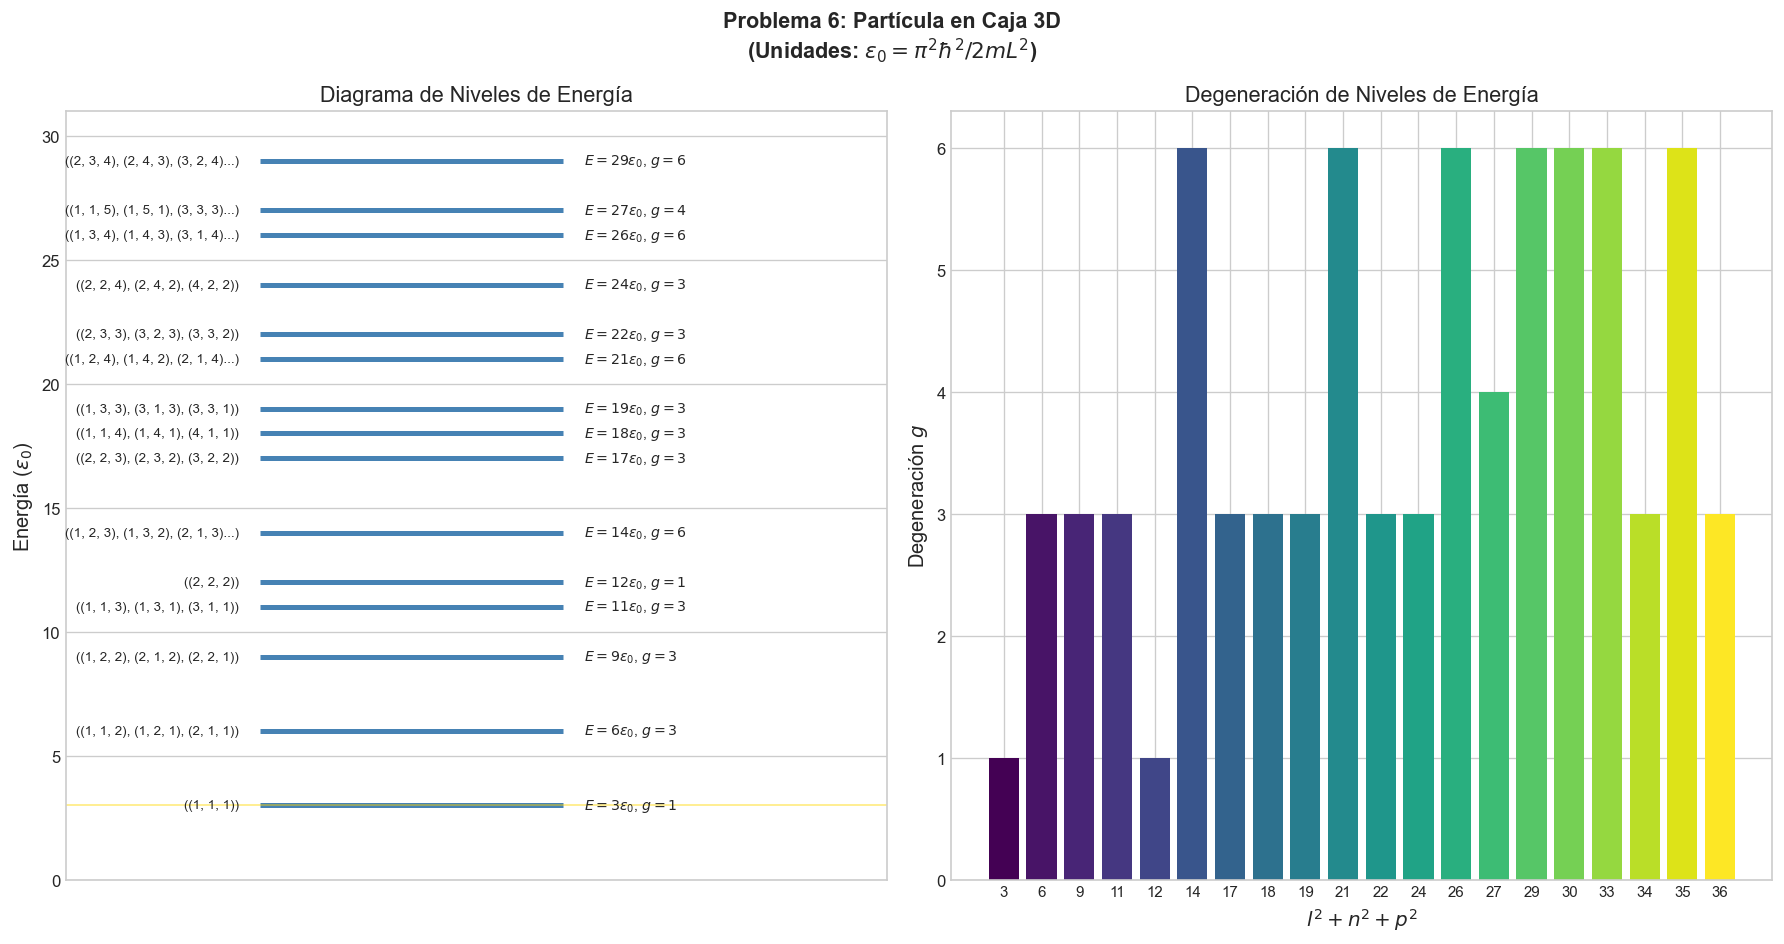

In [4]:
# Partícula en caja 3D — Niveles de energía
levels6 = {}
for l in range(1, 8):
    for n in range(1, 8):
        for p in range(1, 8):
            E = l**2 + n**2 + p**2
            levels6.setdefault(E, []).append((l, n, p))

sorted_E6 = sorted(levels6.keys())[:20]

fig, axes = plt.subplots(1, 2, figsize=(15, 8))
fig.suptitle('Problema 6: Partícula en Caja 3D\n'
             '(Unidades: $\\varepsilon_0 = \\pi^2\\hbar^2/2mL^2$)', fontsize=13, fontweight='bold')

# Diagrama de niveles
ax = axes[0]
for E in sorted_E6[:15]:
    deg = len(levels6[E])
    ax.hlines(E, 0.15, 0.85, colors='steelblue', linewidths=3)
    ax.text(0.90, E, f'$E={E}\\varepsilon_0$, $g={deg}$', va='center', fontsize=8.5)
    qns_str = ', '.join([str(q) for q in levels6[E][:3]])
    if len(levels6[E]) > 3:
        qns_str += '...'
    ax.text(0.10, E, f'({qns_str})', va='center', fontsize=8, ha='right')
ax.set_xlim(-0.3, 1.6)
ax.set_ylim(0, sorted_E6[14]+2)
ax.set_ylabel('Energía ($\\varepsilon_0$)')
ax.set_title('Diagrama de Niveles de Energía')
ax.set_xticks([])
ax.axhline(sorted_E6[0], color='gold', linewidth=1, alpha=0.5)

# Degeneración como función del nivel
degs6 = [len(levels6[E]) for E in sorted_E6]
axes[1].bar(range(len(sorted_E6)), degs6, color=plt.cm.viridis(np.linspace(0,1,len(sorted_E6))))
axes[1].set_xticks(range(len(sorted_E6)))
axes[1].set_xticklabels([str(E) for E in sorted_E6], fontsize=9)
axes[1].set_xlabel('$l^2+n^2+p^2$')
axes[1].set_ylabel('Degeneración $g$')
axes[1].set_title('Degeneración de Niveles de Energía')

plt.tight_layout()
plt.show()

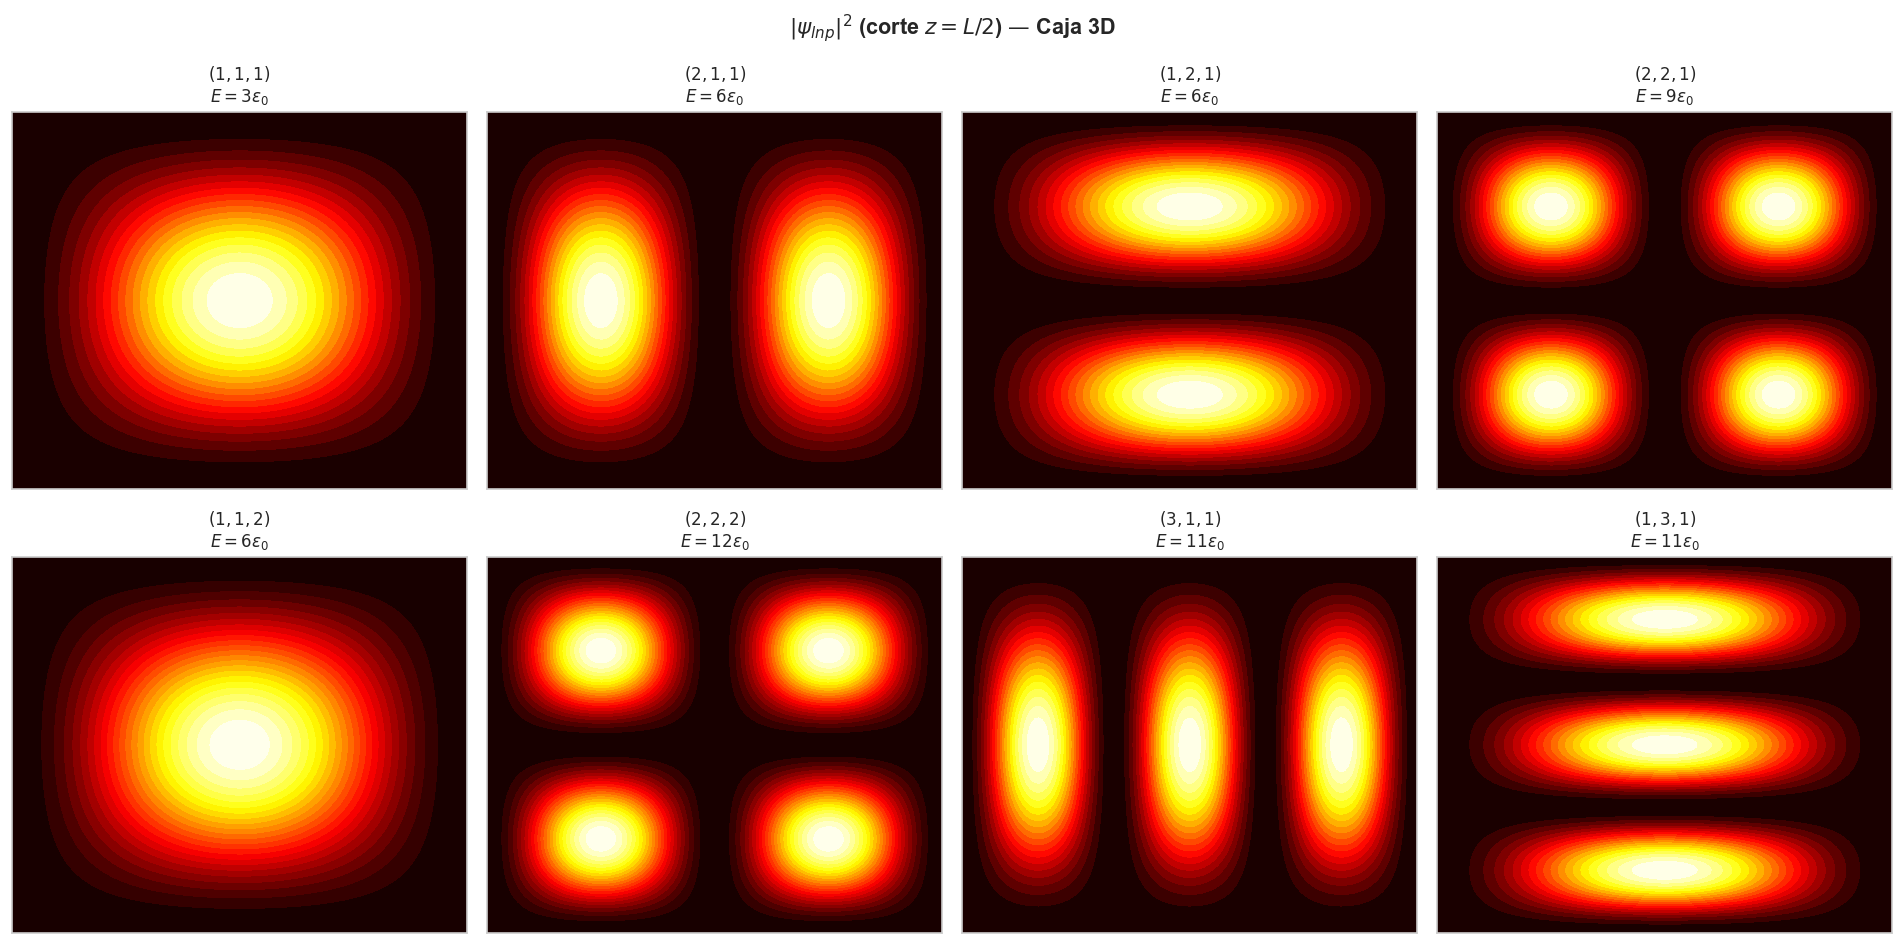

In [5]:
# Densidad de probabilidad |ψ|² para cortes z=L/2
L6 = 1.0
x6 = np.linspace(0, L6, 120)
y6 = np.linspace(0, L6, 120)
X6, Y6 = np.meshgrid(x6, y6)
z_mid = L6/2.0

selected = [(1,1,1),(2,1,1),(1,2,1),(2,2,1),(1,1,2),(2,2,2),(3,1,1),(1,3,1)]

fig = plt.figure(figsize=(16, 8))
fig.suptitle('$|\\psi_{lnp}|^2$ (corte $z=L/2$) — Caja 3D', fontsize=13, fontweight='bold')

for idx, (l, n, p) in enumerate(selected):
    ax = fig.add_subplot(2, 4, idx+1)
    psi2 = (np.sin(l*np.pi*X6/L6)*np.sin(n*np.pi*Y6/L6)*np.sin(p*np.pi*z_mid/L6))**2
    psi2 *= 8/L6**3
    ax.contourf(X6, Y6, psi2, levels=25, cmap='hot')
    E6 = l**2 + n**2 + p**2
    ax.set_title(f'$({l},{n},{p})$\n$E={E6}\\varepsilon_0$', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

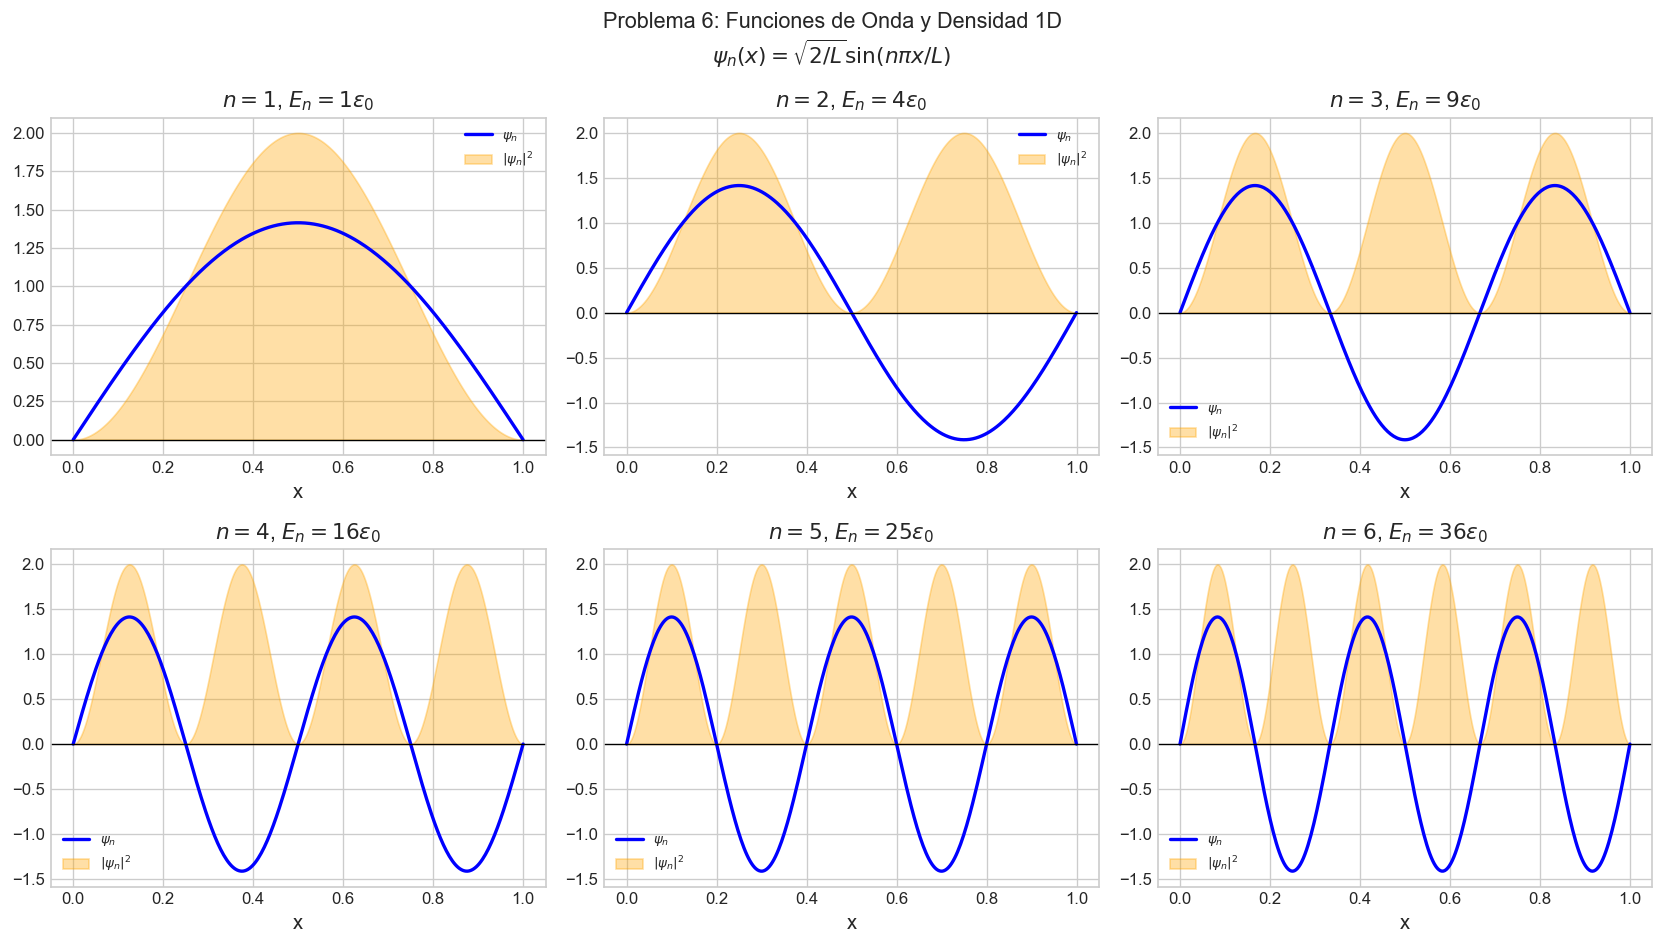

In [6]:
# Funciones de onda 1D y combinaciones
x6_1d = np.linspace(0, L6, 300)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Problema 6: Funciones de Onda y Densidad 1D\n'
             '$\\psi_n(x) = \\sqrt{2/L}\\sin(n\\pi x/L)$', fontsize=13)

for n in range(1, 7):
    row, col = (n-1)//3, (n-1)%3
    psi_n = np.sqrt(2/L6) * np.sin(n*np.pi*x6_1d/L6)
    axes[row,col].plot(x6_1d, psi_n, 'b-', linewidth=2, label='$\\psi_n$')
    axes[row,col].fill_between(x6_1d, psi_n**2, alpha=0.35, color='orange', label='$|\\psi_n|^2$')
    axes[row,col].set_title(f'$n={n}$, $E_n = {n**2}\\varepsilon_0$')
    axes[row,col].set_xlabel('x'); axes[row,col].legend(fontsize=8)
    axes[row,col].axhline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

---
## Problema 7: Placa Semi-infinita

**Dominio:** $x \geq 0$, $0 \leq y \leq b$

**Ecuación de Laplace:** $\nabla^2 T = 0$

**Condiciones de frontera:**
- $T(0,y) = T_0 = 100$ °C (borde caliente)
- $T(x,0) = T(x,b) = 0$ (bordes superior e inferior)
- $T(x,y) \to 0$ cuando $x \to \infty$

### Solución por separación de variables:
$$T(x,y) = \frac{4T_0}{\pi}\sum_{m=1}^{\infty}\frac{1}{2m-1}\sin\!\left(\frac{(2m-1)\pi y}{b}\right)e^{-(2m-1)\pi x/b}$$

Esta es la serie de Fourier seno de la condición $T(0,y)=T_0$ (constante), que da solo armónicos impares.

**Parámetros:** $b=1$, $T_0=100$ °C

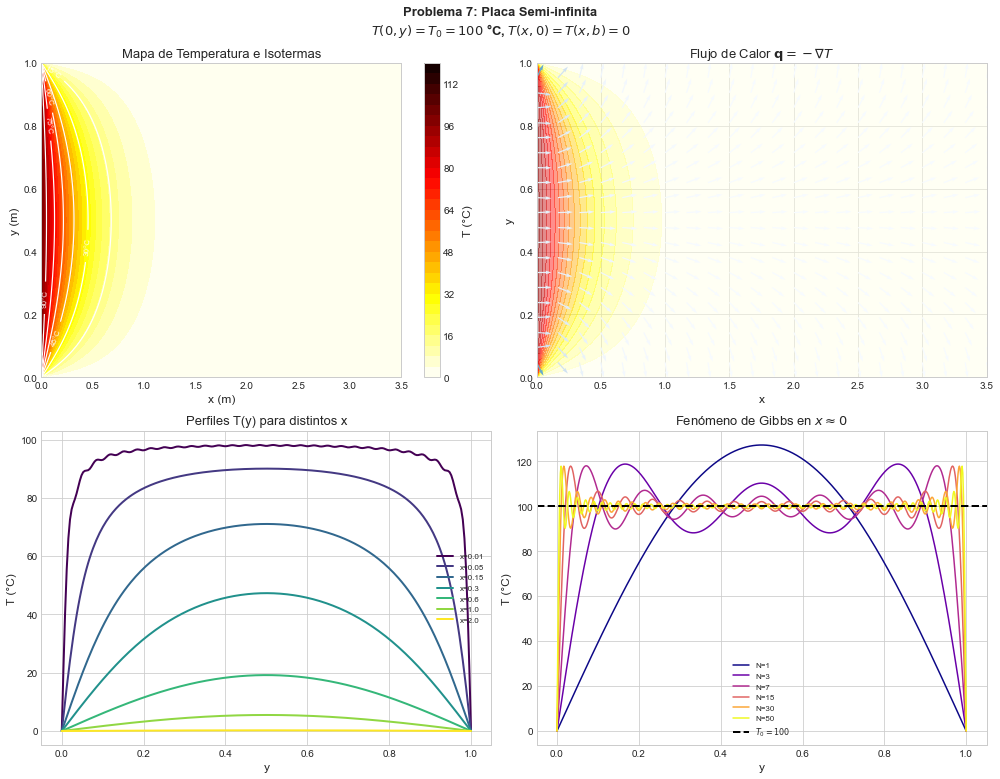

In [19]:
# Placa semi-infinita
b7, T0_7 = 1.0, 100.0
N7 = 30

x7 = np.linspace(0, 3.5, 250)
y7 = np.linspace(0, b7, 250)
X7, Y7 = np.meshgrid(x7, y7)

def T7(x, y, N=N7):
    T = np.zeros_like(x*y, dtype=float)
    for m in range(1, N+1):
        k = 2*m - 1
        T += (1.0/k) * np.sin(k*np.pi*y/b7) * np.exp(-k*np.pi*x/b7)
    return (4.0*T0_7/np.pi) * T

T7_grid = T7(X7, Y7)

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Problema 7: Placa Semi-infinita\n'
             '$T(0,y)=T_0=100$ °C, $T(x,0)=T(x,b)=0$', fontsize=13, fontweight='bold')

# Mapa + isotermas
im7 = axes[0,0].contourf(X7, Y7, T7_grid, levels=30, cmap='hot_r')
cs7 = axes[0,0].contour(X7, Y7, T7_grid, levels=10, colors='white', linewidths=1.2)
axes[0,0].clabel(cs7, fmt='%.0f°C', fontsize=8)
plt.colorbar(im7, ax=axes[0,0], label='T (°C)')
axes[0,0].set_title('Mapa de Temperatura e Isotermas')
axes[0,0].set_xlabel('x (m)'); axes[0,0].set_ylabel('y (m)')

# Flujo de calor
x7c = np.linspace(0, 3.5, 22)
y7c = np.linspace(0, b7, 22)
Xc7, Yc7 = np.meshgrid(x7c, y7c)
T7c = T7(Xc7, Yc7)
dTdx7 = np.gradient(T7c, x7c[1]-x7c[0], axis=1)
dTdy7 = np.gradient(T7c, y7c[1]-y7c[0], axis=0)
qx7, qy7 = -dTdx7, -dTdy7
qmag7 = np.hypot(qx7, qy7); qmag7[qmag7 < 1e-10] = 1e-10
axes[0,1].contourf(X7, Y7, T7_grid, levels=20, cmap='hot_r', alpha=0.45)
axes[0,1].quiver(Xc7, Yc7, qx7/qmag7, qy7/qmag7, qmag7, cmap='Blues', scale=30)
axes[0,1].set_title('Flujo de Calor $\\mathbf{q}=-\\nabla T$')
axes[0,1].set_xlabel('x'); axes[0,1].set_ylabel('y')

# Perfiles T(y) para diferentes x
x_vals7 = [0.01, 0.05, 0.15, 0.3, 0.6, 1.0, 2.0]
clrs7 = plt.cm.viridis(np.linspace(0, 1, len(x_vals7)))
for k, xv in enumerate(x_vals7):
    axes[1,0].plot(y7, T7(xv*np.ones_like(y7), y7),
                   color=clrs7[k], linewidth=2, label=f'x={xv}')
axes[1,0].set_xlabel('y'); axes[1,0].set_ylabel('T (°C)')
axes[1,0].set_title('Perfiles T(y) para distintos x')
axes[1,0].legend(fontsize=8); axes[1,0].grid(True)

# Fenómeno de Gibbs
y_gb = np.linspace(0, b7, 600)
for k, Ng in enumerate([1, 3, 7, 15, 30, 50]):
    clr = plt.cm.plasma(k/5)
    T_gb = T7(1e-7*np.ones_like(y_gb), y_gb, N=Ng)
    axes[1,1].plot(y_gb, T_gb, color=clr, linewidth=1.5, label=f'N={Ng}')
axes[1,1].axhline(T0_7, color='black', linestyle='--', linewidth=2, label='$T_0=100$')
axes[1,1].set_xlabel('y'); axes[1,1].set_ylabel('T (°C)')
axes[1,1].set_title('Fenómeno de Gibbs en $x\\approx 0$')
axes[1,1].legend(fontsize=8); axes[1,1].grid(True)

plt.tight_layout()
plt.show()

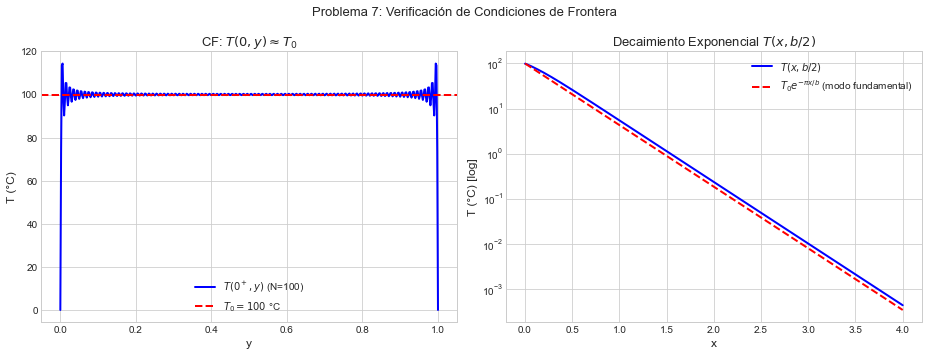

In [20]:
# Verificación de la condición de frontera y decaimiento exponencial
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Problema 7: Verificación de Condiciones de Frontera', fontsize=13)

# T(0,y) ≈ T0
y7_check = np.linspace(0, b7, 500)
T_boundary = T7(1e-6*np.ones_like(y7_check), y7_check, N=100)
axes[0].plot(y7_check, T_boundary, 'b-', linewidth=2, label='$T(0^+, y)$ (N=100)')
axes[0].axhline(T0_7, color='red', linestyle='--', linewidth=2, label='$T_0=100$ °C')
axes[0].set_xlabel('y'); axes[0].set_ylabel('T (°C)')
axes[0].set_title('CF: $T(0,y) \\approx T_0$')
axes[0].legend(); axes[0].grid(True)

# Decaimiento T(x, y=b/2)
x7_dec = np.linspace(0.001, 4, 300)
T_center = T7(x7_dec, (b7/2)*np.ones_like(x7_dec))
axes[1].semilogy(x7_dec, np.abs(T_center), 'b-', linewidth=2, label='$T(x, b/2)$')
# Pendiente teórica: exp(-π x/b)
axes[1].semilogy(x7_dec, T0_7 * np.exp(-np.pi*x7_dec/b7),
                 'r--', linewidth=2, label='$T_0 e^{-\\pi x/b}$ (modo fundamental)')
axes[1].set_xlabel('x'); axes[1].set_ylabel('T (°C) [log]')
axes[1].set_title('Decaimiento Exponencial $T(x, b/2)$')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()

---
## Problema 8: Placa Semi-infinita con Cuatro Condiciones de Frontera

**Ecuación de Laplace:** $\nabla^2 T = 0$, dominio $x\geq 0$, $0\leq y\leq b$

**Condiciones comunes:** $T(x,0)=T(x,b)=0$, $T\to 0$ cuando $x\to\infty$

**Solución general:**
$$T(x,y) = \sum_{n=1}^{\infty} A_n \sin\!\left(\frac{n\pi y}{b}\right) e^{-n\pi x/b}$$

Los coeficientes se determinan de $T(0,y) = f(y)$:
$$A_n = \frac{2}{b}\int_0^b f(y)\sin\!\left(\frac{n\pi y}{b}\right)dy$$

### Cuatro condiciones de frontera:

**(a) Función escalón:** $f(y) = T_0\,\mathbf{1}_{y>b/2}$ (calentada solo la mitad superior)
$$A_n = \frac{2T_0}{n\pi}\left[\cos\!\left(\frac{n\pi}{2}\right)-(-1)^n\right]$$

**(b) Función lineal:** $f(y) = T_0 y/b$
$$A_n = \frac{2T_0}{n\pi}(-1)^{n+1}$$

**(c) Función coseno:** $f(y) = T_0\cos(\pi y/b)$
$$A_n = \frac{2T_0}{\pi}\frac{n(-1)^n - 1}{n^2-1} \quad (n\neq 1), \qquad A_1 = 0$$

**(d) Función seno:** $f(y) = T_0\sin(\pi y/b)$
$$A_1 = T_0, \qquad A_n = 0 \quad (n>1)$$

**Parámetros:** $b=1$, $T_0=100$ °C

In [21]:
# Problema 8: Coeficientes para las 4 condiciones de frontera
b8, T0_8 = 1.0, 100.0
N8 = 25

def An_step(n):
    return (2*T0_8/(n*np.pi)) * (np.cos(n*np.pi/2) - (-1)**n)

def An_linear(n):
    return (2*T0_8/(n*np.pi)) * (-1)**(n+1)

def An_cosine(n):
    if n == 1:
        return 0.0
    return (2*T0_8/np.pi) * (n*(-1)**n - 1) / (n**2 - 1)

def An_sine(n):
    return T0_8 if n == 1 else 0.0

An8 = {
    'step':   np.array([An_step(n)   for n in range(1, N8+1)]),
    'linear': np.array([An_linear(n) for n in range(1, N8+1)]),
    'cosine': np.array([An_cosine(n) for n in range(1, N8+1)]),
    'sine':   np.array([An_sine(n)   for n in range(1, N8+1)]),
}

def T8_gen(x, y, An_list):
    T = np.zeros_like(x*y, dtype=float)
    for n in range(1, N8+1):
        T += An_list[n-1] * np.sin(n*np.pi*y/b8) * np.exp(-n*np.pi*x/b8)
    return T

x8 = np.linspace(0, 3.5, 250)
y8 = np.linspace(0, b8, 250)
X8, Y8 = np.meshgrid(x8, y8)

for case, An_c in An8.items():
    print(f"{case:8s}: A1={An_c[0]:8.3f}, A2={An_c[1]:8.3f}, A3={An_c[2]:8.3f}")

step    : A1=  63.662, A2= -63.662, A3=  21.221
linear  : A1=  63.662, A2= -31.831, A3=  21.221
cosine  : A1=   0.000, A2=  21.221, A3= -31.831
sine    : A1= 100.000, A2=   0.000, A3=   0.000


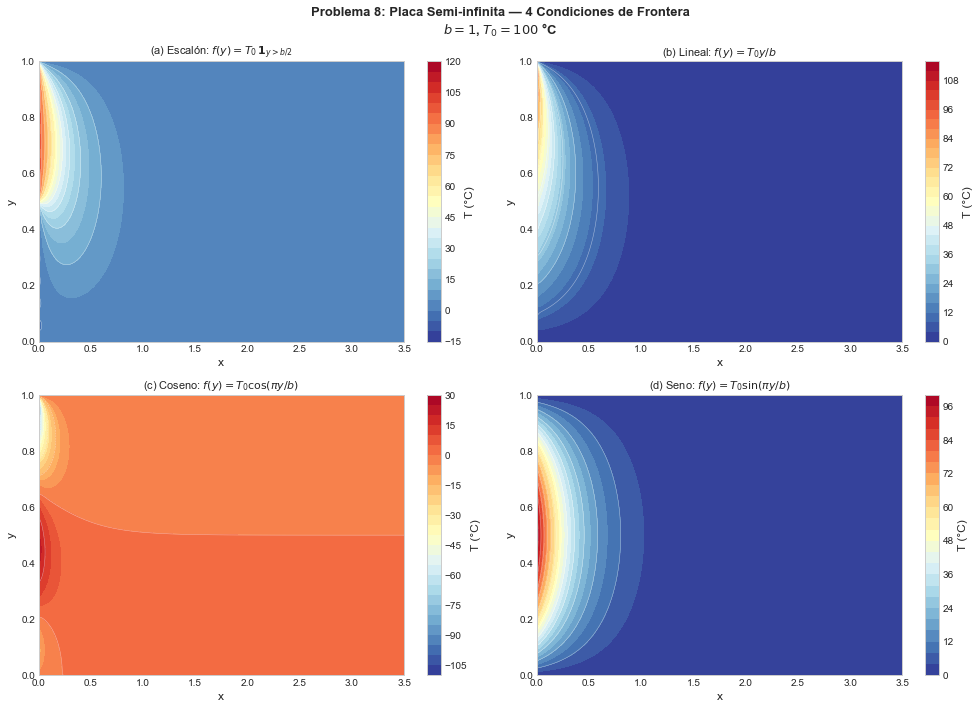

In [22]:
# Mapas de temperatura para las 4 condiciones
titles8 = [
    '(a) Escalón: $f(y)=T_0\\,\\mathbf{1}_{y>b/2}$',
    '(b) Lineal: $f(y)=T_0 y/b$',
    '(c) Coseno: $f(y)=T_0\\cos(\\pi y/b)$',
    '(d) Seno: $f(y)=T_0\\sin(\\pi y/b)$',
]
cases8 = ['step', 'linear', 'cosine', 'sine']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Problema 8: Placa Semi-infinita — 4 Condiciones de Frontera\n'
             '$b=1$, $T_0=100$ °C', fontsize=13, fontweight='bold')

for k, (case, title) in enumerate(zip(cases8, titles8)):
    row, col = k//2, k%2
    T8 = T8_gen(X8, Y8, An8[case])
    im8 = axes[row,col].contourf(X8, Y8, T8, levels=30, cmap='RdYlBu_r')
    axes[row,col].contour(X8, Y8, T8, levels=12, colors='white', linewidths=0.5, alpha=0.55)
    plt.colorbar(im8, ax=axes[row,col], label='T (°C)')
    axes[row,col].set_title(title, fontsize=11)
    axes[row,col].set_xlabel('x'); axes[row,col].set_ylabel('y')

plt.tight_layout()
plt.show()

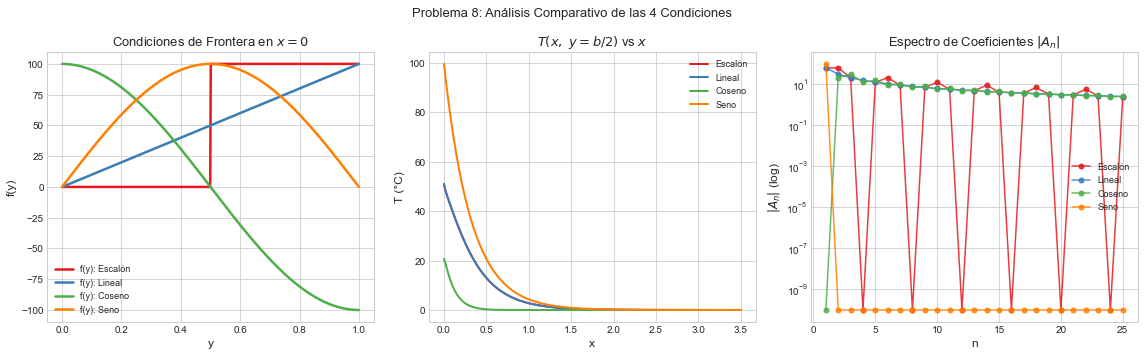

In [23]:
# Comparación de las 4 condiciones: f(y), T(x,b/2) y espectro
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Problema 8: Análisis Comparativo de las 4 Condiciones', fontsize=13)

y8_plot = np.linspace(0, b8, 500)
f_funcs8 = {
    'Escalón':  np.where(y8_plot > b8/2, T0_8, 0.0),
    'Lineal':   T0_8 * y8_plot / b8,
    'Coseno':   T0_8 * np.cos(np.pi*y8_plot/b8),
    'Seno':     T0_8 * np.sin(np.pi*y8_plot/b8),
}
clrs8 = ['#e41a1c', '#377eb8', '#4daf4a', '#ff7f00']
for (name, f_y), col in zip(f_funcs8.items(), clrs8):
    axes[0].plot(y8_plot, f_y, color=col, linewidth=2.5, label=f'f(y): {name}')
axes[0].set_xlabel('y'); axes[0].set_ylabel('f(y)')
axes[0].set_title('Condiciones de Frontera en $x=0$')
axes[0].legend(fontsize=9); axes[0].grid(True)

# T(x) a lo largo de y=b/2
x8_line = np.linspace(0.001, 3.5, 300)
for (case, name, col) in zip(cases8, f_funcs8.keys(), clrs8):
    T_c = T8_gen(x8_line, (b8/2)*np.ones_like(x8_line), An8[case])
    axes[1].plot(x8_line, T_c, color=col, linewidth=2, label=name)
axes[1].set_xlabel('x'); axes[1].set_ylabel('T (°C)')
axes[1].set_title('$T(x,\\ y=b/2)$ vs $x$')
axes[1].legend(fontsize=9); axes[1].grid(True)

# Espectro |A_n|
ns8 = np.arange(1, N8+1)
for (case, name, col) in zip(cases8, f_funcs8.keys(), clrs8):
    axes[2].semilogy(ns8, np.abs(An8[case]) + 1e-10, 'o-', color=col,
                     linewidth=1.5, markersize=5, label=name, alpha=0.85)
axes[2].set_xlabel('n'); axes[2].set_ylabel('$|A_n|$ (log)')
axes[2].set_title('Espectro de Coeficientes $|A_n|$')
axes[2].legend(fontsize=9); axes[2].grid(True)

plt.tight_layout()
plt.show()

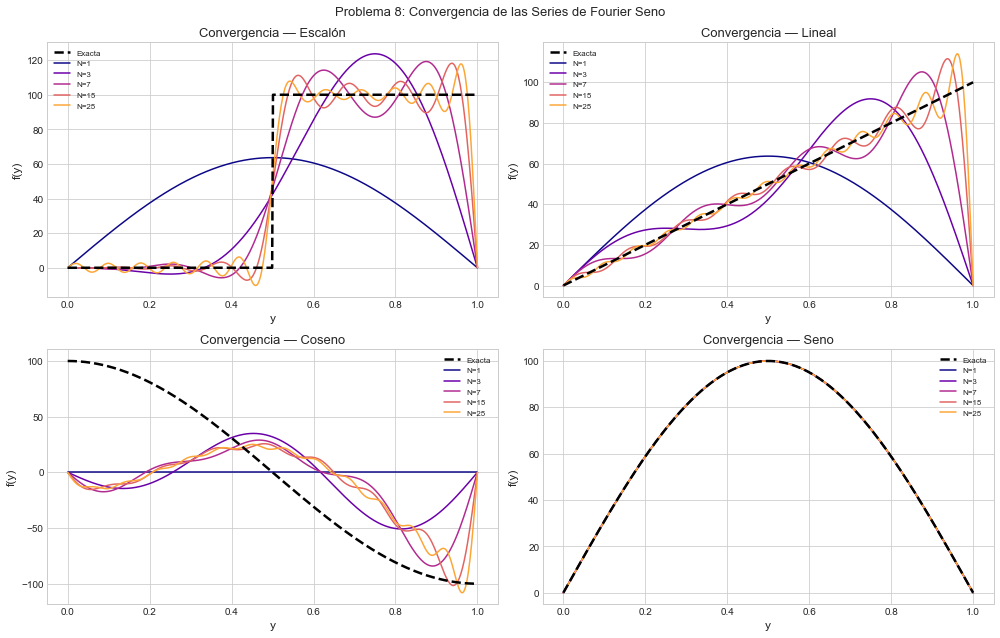

In [24]:
# Reconstrucción de f(y) con la serie de Fourier seno
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Problema 8: Convergencia de las Series de Fourier Seno', fontsize=13)

cases_list  = list(f_funcs8.items())
cases_An    = list(An8.items())
Ns_partial  = [1, 3, 7, 15, 25]

for k in range(4):
    row, col = k//2, k%2
    name, f_exact_8 = cases_list[k]
    _, An_c = cases_An[k]
    axes[row,col].plot(y8_plot, f_exact_8, 'k--', linewidth=2.5, label='Exacta', zorder=5)
    clrs_conv = plt.cm.plasma(np.linspace(0, 0.8, len(Ns_partial)))
    for j, Np in enumerate(Ns_partial):
        T_partial = np.zeros_like(y8_plot)
        for n in range(1, Np+1):
            T_partial += An_c[n-1] * np.sin(n*np.pi*y8_plot/b8)
        axes[row,col].plot(y8_plot, T_partial, color=clrs_conv[j],
                           linewidth=1.5, label=f'N={Np}')
    axes[row,col].set_title(f'Convergencia — {name}')
    axes[row,col].set_xlabel('y'); axes[row,col].set_ylabel('f(y)')
    axes[row,col].legend(fontsize=8); axes[row,col].grid(True)

plt.tight_layout()
plt.show()

---
## Resumen Final

| Problema | Tema | Método | Solución |
|----------|------|--------|----------|
| 1 | Clasificación EDPs | Discriminante $B^2-4AC$ | Elíptica/Parabólica/Hiperbólica según región |
| 2 | Potencial Electrostático | Laplace | $\varphi=\sin(5\pi x/L)e^{-5\pi y/L}$ |
| 3 | Membrana Rectangular | Sep. Variables | $u_{mn}=\sin(m\pi x/a)\sin(n\pi y/b)\cos(\omega_{mn}t)$ |
| 4 | Difusión con Pérdida | Serie Fourier coseno | $T\sim e^{-\alpha_n t}$, $\alpha_n=h+\kappa(n\pi/L)^2$ |
| 5 | Cuerda Vibrante | Serie Fourier seno | $B_n\sim 1/n^3$ (impares), convergencia cúbica |
| 6 | Caja 3D | Sep. Variables | $E_{lnp}=\varepsilon_0(l^2+n^2+p^2)$, degeneración |
| 7 | Placa Semi-infinita | Fourier seno | $T\sim\sum(1/n)\sin(n\pi y/b)e^{-n\pi x/b}$ |
| 8 | Placa 4 CFs | Fourier seno | $A_n$ depende de la condición de frontera |

### Conceptos clave:
- **Separación de variables** como método fundamental para resolver EDPs lineales
- Los **coeficientes de Fourier** capturan la información de las condiciones iniciales/frontera
- La **convergencia** de la serie depende de la suavidad de la condición de frontera ($1/n^3$ para discontinuidades en derivadas, $1/n$ para discontinuidades)
- El **fenómeno de Gibbs** aparece cerca de discontinuidades (Problem 7, CFs escalón)

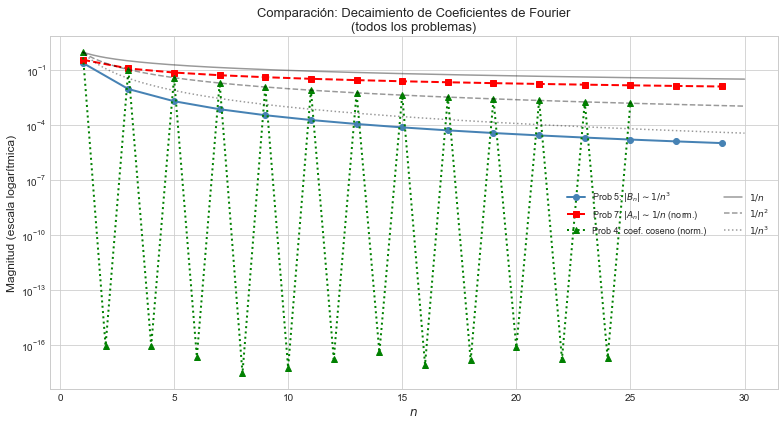

\n¡Cuaderno ejecutado completamente!


In [25]:
# Figura comparativa final: decaimiento de coeficientes en todos los problemas
fig, ax = plt.subplots(figsize=(11, 6))
ax.set_title('Comparación: Decaimiento de Coeficientes de Fourier\n(todos los problemas)', fontsize=13)

ns_all = np.arange(1, 31, dtype=float)

# Prob 5: 1/n^3 (solo impares)
ns_odd5 = 2*np.arange(1, 16) - 1
Bn5 = 8*L5**2/np.pi**3 / ns_odd5**3
ax.semilogy(ns_odd5, Bn5, 'o-', color='steelblue', linewidth=2, label='Prob 5: $|B_n|\\sim 1/n^3$')

# Prob 7: 1/n (solo impares)
ns_odd7 = 2*np.arange(1, 16) - 1
Bn7 = (4*T0_7/np.pi) / ns_odd7
ax.semilogy(ns_odd7, Bn7/T0_7*0.3, 's--', color='red', linewidth=2, label='Prob 7: $|A_n|\\sim 1/n$ (norm.)')

# Prob 4
ax.semilogy(ns_all[:N4], np.abs(An4)/np.abs(An4[0]), '^:', color='green', linewidth=2, label='Prob 4: coef. coseno (norm.)')

# Referencias teóricas
ns_ref = np.linspace(1, 30, 200)
ax.semilogy(ns_ref, 1/ns_ref,    'k-',  alpha=0.4, linewidth=1.5, label='$1/n$')
ax.semilogy(ns_ref, 1/ns_ref**2, 'k--', alpha=0.4, linewidth=1.5, label='$1/n^2$')
ax.semilogy(ns_ref, 1/ns_ref**3, 'k:',  alpha=0.4, linewidth=1.5, label='$1/n^3$')

ax.set_xlabel('$n$'); ax.set_ylabel('Magnitud (escala logarítmica)')
ax.legend(fontsize=9, ncol=2); ax.grid(True)
plt.tight_layout()
plt.show()
print("\\n¡Cuaderno ejecutado completamente!")

### Problema 1 — Análisis Detallado por Regiones

**Ecuación 1:** $\Delta = 4y^2(x^2+x-1)$

Las raíces de $x^2+x-1=0$ son $x = \frac{-1\pm\sqrt{5}}{2}$, es decir $x\approx -1.618$ y $x\approx 0.618$.

- **Elíptica ($\Delta<0$):** $y\neq 0$ y $x^2+x-1<0$ (franja $-1.618 < x < 0.618$)  
- **Hiperbólica ($\Delta>0$):** $y\neq 0$ y $x^2+x-1>0$ (exterior de la franja)  
- **Parabólica ($\Delta=0$):** eje $y=0$ o las líneas $x=\frac{-1\pm\sqrt{5}}{2}$

**Ecuación 4:** $\Delta = -4xy$ — Esta es la **Ecuación de Tricomi** generalizada, importante en aerodinámica (transición subsónica-supersónica).

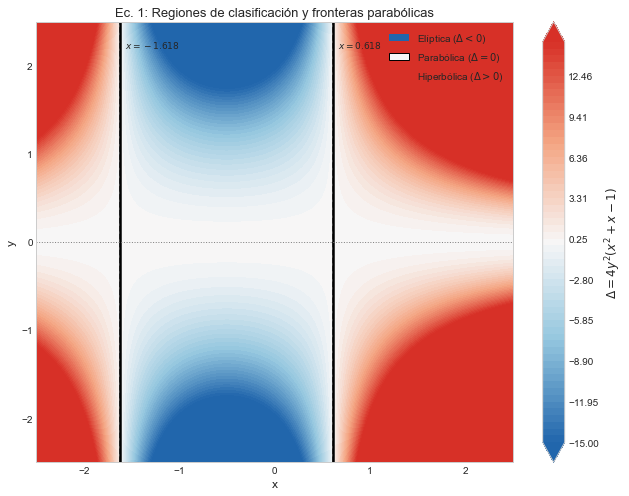

In [26]:
# Fronteras de clasificación - Ecuación 1
fig, ax = plt.subplots(figsize=(9, 7))
x_cls = np.linspace(-2.5, 2.5, 500)
y_cls = np.linspace(-2.5, 2.5, 500)
Xcls, Ycls = np.meshgrid(x_cls, y_cls)
D1_cls = 4*Ycls**2*(Xcls**2+Xcls-1)

cmap_cls2 = mcolors.LinearSegmentedColormap.from_list('cls2',
    ['#2166ac','#92c5de','#f7f7f7','#f4a582','#d73027'], N=256)
im = ax.contourf(Xcls, Ycls, D1_cls, levels=np.linspace(-15,15,60), cmap=cmap_cls2, extend='both')
ax.contour(Xcls, Ycls, D1_cls, levels=[0], colors='black', linewidths=2.5)
plt.colorbar(im, ax=ax, label='$\\Delta = 4y^2(x^2+x-1)$')

x_roots = [(-1-np.sqrt(5))/2, (-1+np.sqrt(5))/2]
for xr in x_roots:
    ax.axvline(xr, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.text(xr+0.05, 2.2, f'$x={xr:.3f}$', fontsize=9)

ax.axhline(0, color='gray', linestyle=':', linewidth=1)
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Ec. 1: Regiones de clasificación y fronteras parabólicas')

from matplotlib.patches import Patch
lp = [Patch(fc='#2166ac', label='Elíptica ($\\Delta<0$)'),
      Patch(fc='#f7f7f7', ec='k', label='Parabólica ($\\Delta=0$)'),
      Patch(fc='#d73027', label='Hiperbólica ($\\Delta>0$)')]
ax.legend(handles=lp, fontsize=10)
plt.tight_layout()
plt.show()

### Problema 2 — Perfil del Potencial y Campo

El potencial decae exponencialmente en la dirección $y$ con longitud de escala $\lambda = L/(5\pi)$.  
En la dirección $x$ oscila con periodo $L/5$.

**Densidad de energía eléctrica:** $u_E = \frac{\varepsilon_0}{2}|\mathbf{E}|^2$

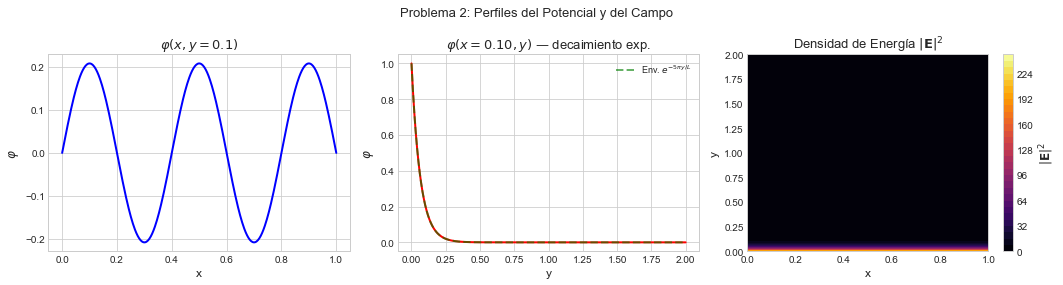

In [27]:
# Perfiles del potencial y campo eléctrico
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Problema 2: Perfiles del Potencial y del Campo', fontsize=13)

L_p2 = 1.0
x_prof = np.linspace(0, L_p2, 400)
y_prof = np.linspace(0, 2.0, 400)

# phi vs x (a y=0.1)
y_fixed = 0.1
phi_x = np.sin(5*np.pi*x_prof/L_p2)*np.exp(-5*np.pi*y_fixed/L_p2)
axes[0].plot(x_prof, phi_x, 'b-', linewidth=2)
axes[0].set_xlabel('x'); axes[0].set_ylabel('$\\varphi$')
axes[0].set_title(f'$\\varphi(x, y={y_fixed})$')
axes[0].grid(True)

# phi vs y (a x=L/10)
x_fixed = L_p2/10
phi_y = np.sin(5*np.pi*x_fixed/L_p2)*np.exp(-5*np.pi*y_prof/L_p2)
axes[1].plot(y_prof, phi_y, 'r-', linewidth=2)
axes[1].plot(y_prof, np.sin(5*np.pi*x_fixed/L_p2)*np.exp(-5*np.pi*y_prof/L_p2), 'g--',
             linewidth=2, alpha=0.6, label='Env. $e^{-5\\pi y/L}$')
axes[1].set_xlabel('y'); axes[1].set_ylabel('$\\varphi$')
axes[1].set_title(f'$\\varphi(x={x_fixed:.2f}, y)$ — decaimiento exp.')
axes[1].legend(fontsize=9); axes[1].grid(True)

# |E|² density
x2d = np.linspace(0, L_p2, 200)
y2d = np.linspace(0, 2.0, 200)
X2d, Y2d = np.meshgrid(x2d, y2d)
Ex2 = -(5*np.pi/L_p2)*np.cos(5*np.pi*X2d/L_p2)*np.exp(-5*np.pi*Y2d/L_p2)
Ey2 =  (5*np.pi/L_p2)*np.sin(5*np.pi*X2d/L_p2)*np.exp(-5*np.pi*Y2d/L_p2)
E2_density = Ex2**2 + Ey2**2
im2d = axes[2].contourf(X2d, Y2d, E2_density, levels=30, cmap='inferno')
plt.colorbar(im2d, ax=axes[2], label='$|\\mathbf{E}|^2$')
axes[2].set_title('Densidad de Energía $|\\mathbf{E}|^2$')
axes[2].set_xlabel('x'); axes[2].set_ylabel('y')

plt.tight_layout()
plt.show()

### Problema 3 — Tabla de Modos y Degeneración

Para la membrana con $a=2$, $b=1.5$, en general no existe degeneración excepto por razones especiales.

La frecuencia fundamental es:
$$\omega_{11} = \pi v\sqrt{\frac{1}{4}+\frac{1}{2.25}} = \pi\sqrt{\frac{1}{4}+\frac{4}{9}} \approx \pi \cdot 0.7454$$

El **modo más lento** corresponde a $(m,n)=(1,1)$ y el **espectro es discreto** y acumulable en
$\omega_{mn}$ creciente.

In [28]:
# Tabla de frecuencias y nodos para varios modos
print(f"{'Modo (m,n)':12s} {'omega_mn':10s} {'T_mn':10s} {'Nodos x':8s} {'Nodos y':8s}")
print('-'*52)
for m in range(1, 5):
    for n in range(1, 5):
        om = np.pi*v_mem*np.sqrt((m/a_mem)**2+(n/b_mem)**2)
        T_mn = 2*np.pi/om
        print(f"({m},{n})       {om:10.4f} {T_mn:10.4f} {m-1:8d} {n-1:8d}")

Modo (m,n)   omega_mn   T_mn       Nodos x  Nodos y 
----------------------------------------------------
(1,1)           2.6180     2.4000        0        0
(1,2)           4.4736     1.4045        0        1
(1,3)           6.4766     0.9701        0        2
(1,4)           8.5236     0.7372        0        3
(2,1)           3.7757     1.6641        1        0
(2,2)           5.2360     1.2000        1        1
(2,3)           7.0248     0.8944        1        2
(2,4)           8.9473     0.7022        1        3
(3,1)           5.1568     1.2184        2        0
(3,2)           6.3050     0.9965        2        1
(3,3)           7.8540     0.8000        2        2
(3,4)           9.6120     0.6537        2        3
(4,1)           6.6231     0.9487        3        0
(4,2)           7.5514     0.8321        3        1
(4,3)           8.8858     0.7071        3        2
(4,4)          10.4720     0.6000        3        3


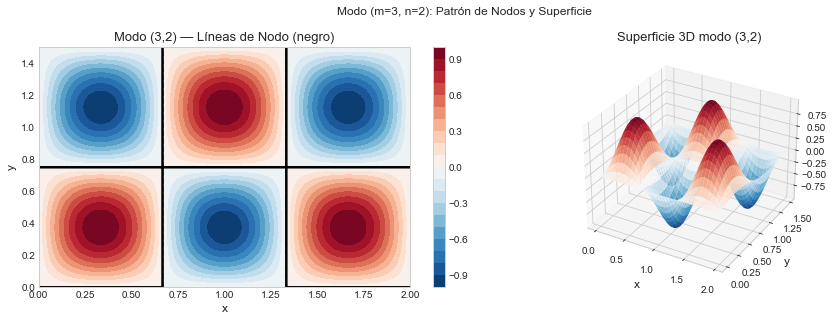

In [29]:
# Análisis de nodos: mapa de nodos para el modo (3,2)
m_nd, n_nd = 3, 2
x_nd = np.linspace(0, a_mem, 300)
y_nd = np.linspace(0, b_mem, 300)
Xnd, Ynd = np.meshgrid(x_nd, y_nd)
U_nd = np.sin(m_nd*np.pi*Xnd/a_mem)*np.sin(n_nd*np.pi*Ynd/b_mem)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle(f'Modo (m={m_nd}, n={n_nd}): Patrón de Nodos y Superficie', fontsize=12)

# Mapa con líneas de nodo
im_nd = axes[0].contourf(Xnd, Ynd, U_nd, levels=20, cmap='RdBu_r')
axes[0].contour(Xnd, Ynd, U_nd, levels=[0], colors='black', linewidths=2.5)
plt.colorbar(im_nd, ax=axes[0])
# Marcar líneas de nodo teóricas
for k in range(1, m_nd):
    axes[0].axvline(k*a_mem/m_nd, color='k', linestyle='--', linewidth=1.5, alpha=0.6)
for k in range(1, n_nd):
    axes[0].axhline(k*b_mem/n_nd, color='k', linestyle='--', linewidth=1.5, alpha=0.6)
axes[0].set_title(f'Modo ({m_nd},{n_nd}) — Líneas de Nodo (negro)')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')

ax_3d_nd = axes[1]
ax_3d_nd.remove()
ax_3d_nd = fig.add_subplot(1,2,2, projection='3d')
step_nd = 4
ax_3d_nd.plot_surface(Xnd[::step_nd,::step_nd], Ynd[::step_nd,::step_nd],
                       U_nd[::step_nd,::step_nd], cmap='RdBu_r', alpha=0.88)
ax_3d_nd.set_xlabel('x'); ax_3d_nd.set_ylabel('y'); ax_3d_nd.set_zlabel('u')
ax_3d_nd.set_title(f'Superficie 3D modo ({m_nd},{n_nd})')

plt.tight_layout()
plt.show()

### Problema 4 — Temperatura en un Punto Específico vs Tiempo

En el punto $x = L/2$ (centro de la barra), la temperatura evoluciona como:
$$T(L/2, t) = A_0 e^{-ht} + \sum_{n=1}^{\infty} A_n \cos\!\left(\frac{n\pi}{2}\right) e^{-\alpha_n t}$$

Solo los modos impares contribuyen en $x=L/2$ (ya que $\cos(n\pi/2)=0$ para $n$ par).

La temperatura tiende a $0$ exponencialmente con tasa dominada por $h$ cuando $h\gg\kappa(\pi/L)^2$.

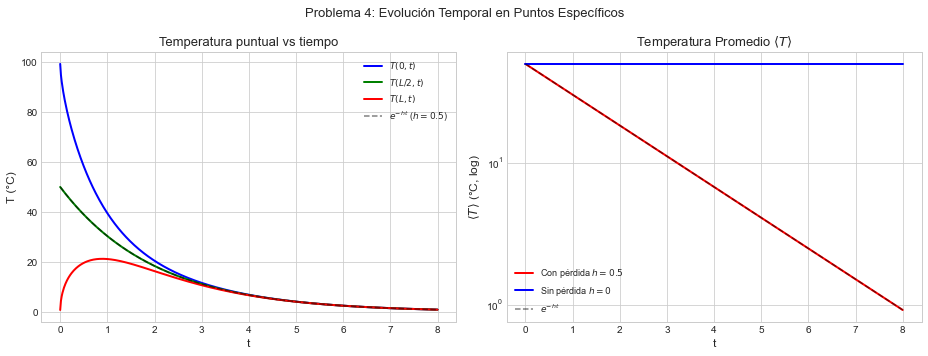

In [31]:
# Evolución temporal T(L/2, t) y T(0, t)
t4_long = np.linspace(0, 8, 500)
T_center4 = np.array([T4_sol(np.array([L4/2]), t)[0] for t in t4_long])
T_left4   = np.array([T4_sol(np.array([0.0]),  t)[0] for t in t4_long])
T_right4  = np.array([T4_sol(np.array([L4]),   t)[0] for t in t4_long])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Problema 4: Evolución Temporal en Puntos Específicos', fontsize=13)

axes[0].plot(t4_long, T_left4,   'b-',  linewidth=2, label='$T(0, t)$')
axes[0].plot(t4_long, T_center4, 'g-',  linewidth=2, label='$T(L/2, t)$')
axes[0].plot(t4_long, T_right4,  'r-',  linewidth=2, label='$T(L, t)$')
# Theoretical decay rate
axes[0].plot(t4_long, T_center4[0]*np.exp(-h4*t4_long), 'k--',
             alpha=0.5, linewidth=1.5, label=f'$e^{{-h t}}$ ($h={h4}$)')
axes[0].set_xlabel('t'); axes[0].set_ylabel('T (°C)')
axes[0].set_title('Temperatura puntual vs tiempo')
axes[0].legend(fontsize=9); axes[0].grid(True)

# Temperatura promedio
T4_avg = np.array([np.trapz(T4_sol(x4, t), x4)/L4 for t in t4_long])
T4_avg_nl = np.array([np.trapz(T4_noloss(x4, t), x4)/L4 for t in t4_long])
axes[1].semilogy(t4_long, np.abs(T4_avg)+1e-12,    'r-', linewidth=2, label='Con pérdida $h=0.5$')
axes[1].semilogy(t4_long, np.abs(T4_avg_nl)+1e-12, 'b-', linewidth=2, label='Sin pérdida $h=0$')
axes[1].semilogy(t4_long, T4_avg[0]*np.exp(-h4*t4_long), 'k--',
                 alpha=0.5, linewidth=1.5, label='$e^{-ht}$')
axes[1].set_xlabel('t'); axes[1].set_ylabel('$\\langle T\\rangle$ (°C, log)')
axes[1].set_title('Temperatura Promedio $\\langle T\\rangle$')
axes[1].legend(fontsize=9); axes[1].grid(True)

plt.tight_layout()
plt.show()

### Problema 5 — Modos Normales de la Cuerda

La condición inicial $f(x) = x(x-L)$ puede descomponerse en los modos normales:
$$f(x) = \sum_{n=1,3,5,...} B_n \sin\!\left(\frac{n\pi x}{L}\right)$$

La parábola $x(x-L)$ es **antisimétrica respecto al punto medio** $x=L/2$ — en sentido de que $f(L/2+\xi) = f(L/2-\xi)$, lo que garantiza que solo aparecen los armónicos impares.

**Energía total de la cuerda:**
$$E = \frac{\rho}{2}\int_0^L\left[\left(\frac{\partial u}{\partial t}\right)^2 + v^2\left(\frac{\partial u}{\partial x}\right)^2\right]dx = \text{constante}$$

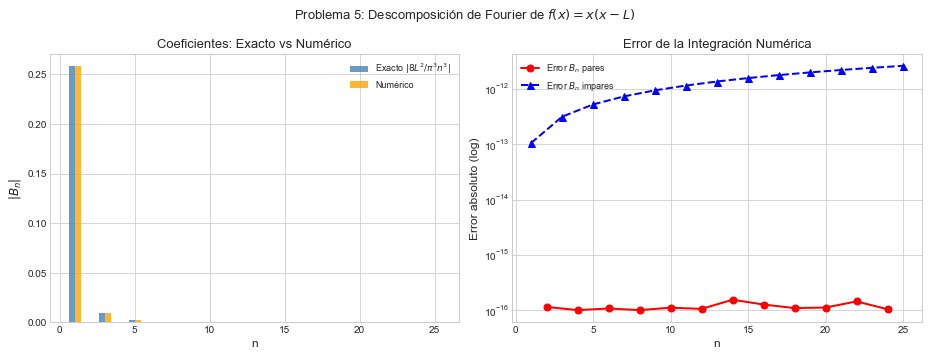

In [33]:
# Análisis espectral de la condición inicial parabólica
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Problema 5: Descomposición de Fourier de $f(x)=x(x-L)$', fontsize=13)

x5_spec = np.linspace(0, L5, 1000)
f5_exact = x5_spec*(x5_spec - L5)

# Coeficientes exactos e integrales numéricas
ns_all5 = np.arange(1, 26)
Bn5_exact = np.zeros(len(ns_all5))
Bn5_num   = np.zeros(len(ns_all5))
for i, n in enumerate(ns_all5):
    if n % 2 == 1:
        Bn5_exact[i] = -8*L5**2/(np.pi**3 * n**3)
    Bn5_num[i] = 2/L5 * np.trapz(f5_exact*np.sin(n*np.pi*x5_spec/L5), x5_spec)

axes[0].bar(ns_all5-0.2, np.abs(Bn5_exact), 0.4, label='Exacto $|8L^2/\\pi^3 n^3|$', color='steelblue', alpha=0.8)
axes[0].bar(ns_all5+0.2, np.abs(Bn5_num),   0.4, label='Numérico', color='orange', alpha=0.8)
axes[0].set_xlabel('n'); axes[0].set_ylabel('$|B_n|$')
axes[0].set_title('Coeficientes: Exacto vs Numérico')
axes[0].legend(fontsize=9); axes[0].grid(True)

# Error relativo para n par (deben ser cero)
err_pares = np.abs(Bn5_num[1::2])
ns_pares  = ns_all5[1::2]
axes[1].semilogy(ns_pares, err_pares+1e-16, 'ro-', markersize=7, linewidth=2, label='Error $B_n$ pares')
axes[1].semilogy(ns_all5[::2], np.abs(Bn5_num[::2]-Bn5_exact[::2])+1e-16, 'b^--',
                 markersize=7, linewidth=2, label='Error $B_n$ impares')
axes[1].set_xlabel('n'); axes[1].set_ylabel('Error absoluto (log)')
axes[1].set_title('Error de la Integración Numérica')
axes[1].legend(fontsize=9); axes[1].grid(True)

plt.tight_layout()
plt.show()

### Problema 6 — Valores Esperados y Principio de Incertidumbre

Para el estado fundamental $(l,n,p)=(1,1,1)$:

$$\langle x\rangle = \langle y\rangle = \langle z\rangle = \frac{L}{2}$$

$$\langle x^2\rangle = \frac{L^2}{3} - \frac{L^2}{2\pi^2} \approx 0.283\,L^2$$

$$\Delta x = \sqrt{\langle x^2\rangle - \langle x\rangle^2} = L\sqrt{\frac{1}{3}-\frac{1}{2\pi^2}-\frac{1}{4}} \approx 0.180\,L$$

**Principio de incertidumbre de Heisenberg:** $\Delta x\,\Delta p_x \geq \hbar/2$

In [34]:
# Valores esperados para la caja cúbica
L6b = 1.0
x6e = np.linspace(0, L6b, 2000)

print("Valores esperados para caja cúbica (L=1)")
print(f"{'(l,n,p)':10s} {'<x>':8s} {'<x²>':8s} {'Δx':8s} {'E (ε₀)':8s}")
print('-'*50)

for l, n, p in [(1,1,1),(2,1,1),(1,2,1),(2,2,1),(2,2,2),(3,1,1)]:
    psi_x = np.sqrt(2/L6b)*np.sin(l*np.pi*x6e/L6b)
    psi2_x = psi_x**2
    x_avg  = np.trapz(x6e * psi2_x, x6e)
    x2_avg = np.trapz(x6e**2 * psi2_x, x6e)
    delta_x = np.sqrt(x2_avg - x_avg**2)
    E6e = l**2 + n**2 + p**2
    print(f"({l},{n},{p})     {x_avg:8.4f} {x2_avg:8.4f} {delta_x:8.4f} {E6e:8d}")

print(f"\nValor teórico <x> = L/2 = {L6b/2:.4f}")
print(f"Valor teórico Δx(1,1,1) = {L6b*np.sqrt(1/3 - 1/(2*np.pi**2) - 1/4):.4f}")

Valores esperados para caja cúbica (L=1)
(l,n,p)    <x>      <x²>     Δx       E (ε₀)  
--------------------------------------------------
(1,1,1)       0.5000   0.2827   0.1808        3
(2,1,1)       0.5000   0.3207   0.2658        6
(1,2,1)       0.5000   0.2827   0.1808        6
(2,2,1)       0.5000   0.3207   0.2658        9
(2,2,2)       0.5000   0.3207   0.2658       12
(3,1,1)       0.5000   0.3277   0.2788       11

Valor teórico <x> = L/2 = 0.5000
Valor teórico Δx(1,1,1) = 0.1808


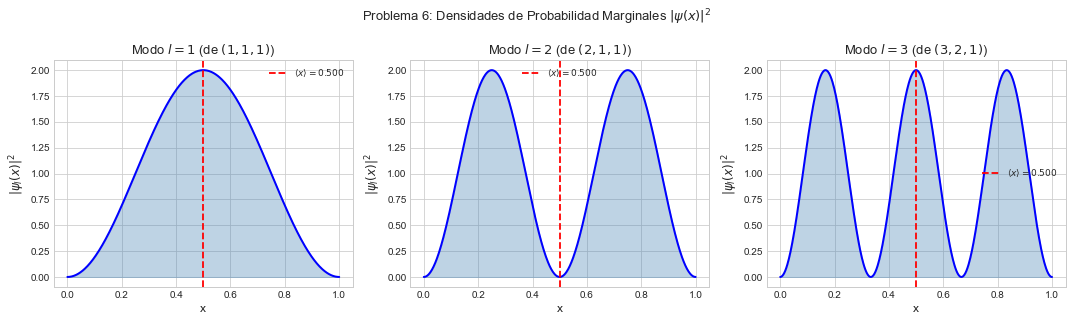

In [35]:
# Densidad de probabilidad integrada (proyección)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle('Problema 6: Densidades de Probabilidad Marginales $|\\psi(x)|^2$', fontsize=13)

L6m = 1.0
x6m = np.linspace(0, L6m, 500)
for idx, (l, n, p) in enumerate([(1,1,1),(2,1,1),(3,2,1)]):
    psi2_m = (2/L6m) * np.sin(l*np.pi*x6m/L6m)**2
    axes[idx].fill_between(x6m, psi2_m, alpha=0.35, color='steelblue')
    axes[idx].plot(x6m, psi2_m, 'b-', linewidth=2)
    # Marcar posición media
    x_bar = np.trapz(x6m*psi2_m, x6m)
    axes[idx].axvline(x_bar, color='red', linestyle='--', linewidth=1.8, label=f'$\\langle x\\rangle={x_bar:.3f}$')
    axes[idx].set_xlabel('x'); axes[idx].set_ylabel('$|\\psi_l(x)|^2$')
    axes[idx].set_title(f'Modo $l={l}$ (de $({l},{n},{p})$)')
    axes[idx].legend(fontsize=9); axes[idx].grid(True)

plt.tight_layout()
plt.show()

### Problema 7 — Flujo de Calor y Balance Energético

El **flujo de calor** (vector de Fourier) es $\mathbf{q} = -k\nabla T$:

$$q_x = -k\frac{\partial T}{\partial x} = k\frac{4T_0}{b}\sum_{m=1}^{\infty}\sin\!\left(\frac{(2m-1)\pi y}{b}\right)e^{-(2m-1)\pi x/b}$$

$$q_y = -k\frac{\partial T}{\partial y} = -k\frac{4T_0}{b}\sum_{m=1}^{\infty}\cos\!\left(\frac{(2m-1)\pi y}{b}\right)e^{-(2m-1)\pi x/b}$$

El flujo total que entra por el borde $x=0$ es:
$$Q_{in} = -k\int_0^b q_x\big|_{x=0}\,dy = k\int_0^b \frac{\partial T}{\partial x}\big|_{x=0}\,dy$$

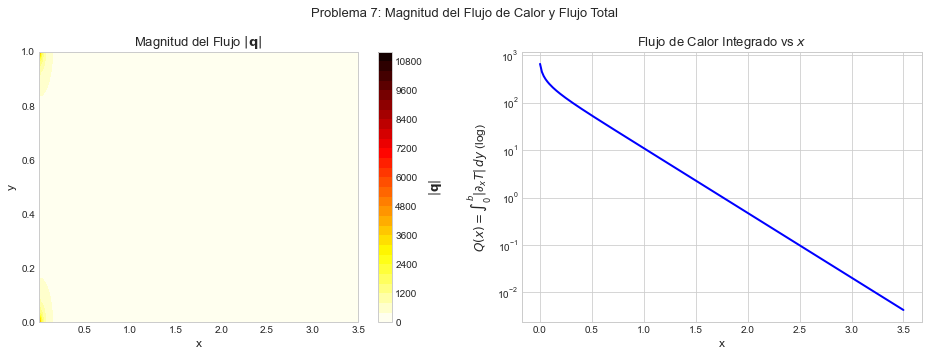

In [37]:
# Flujo de calor en la placa semi-infinita
b7e, T0_7e = 1.0, 100.0
N7e = 30

x7e = np.linspace(0.001, 3.5, 300)
y7e = np.linspace(0, b7e, 300)
X7e, Y7e = np.meshgrid(x7e, y7e)

def dTdx7(x, y, N=N7e):
    dT = np.zeros_like(x*y, dtype=float)
    for m in range(1, N+1):
        k = 2*m-1
        dT += -(k*np.pi/b7e)*(1.0/k)*np.sin(k*np.pi*y/b7e)*np.exp(-k*np.pi*x/b7e)
    return (4*T0_7e/np.pi)*dT

def dTdy7(x, y, N=N7e):
    dT = np.zeros_like(x*y, dtype=float)
    for m in range(1, N+1):
        k = 2*m-1
        dT += (np.pi/b7e)*(1.0)*np.cos(k*np.pi*y/b7e)*np.exp(-k*np.pi*x/b7e)
    return (4*T0_7e/np.pi)*dT

qx7e = -dTdx7(X7e, Y7e)
qy7e = -dTdy7(X7e, Y7e)
qmag7e = np.hypot(qx7e, qy7e)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Problema 7: Magnitud del Flujo de Calor y Flujo Total', fontsize=13)

im7e = axes[0].contourf(X7e, Y7e, qmag7e, levels=30, cmap='hot_r')
plt.colorbar(im7e, ax=axes[0], label='$|\\mathbf{q}|$')
axes[0].set_title('Magnitud del Flujo $|\\mathbf{q}|$')
axes[0].set_xlabel('x'); axes[0].set_ylabel('y')

# Flujo total que entra por x=x0 (función de x)
x7_flux = np.linspace(0.001, 3.5, 200)
y7_int  = np.linspace(0, b7e, 500)
Q_flux  = np.array([np.trapz(np.abs(dTdx7(xv*np.ones_like(y7_int), y7_int)), y7_int)
                    for xv in x7_flux])
axes[1].semilogy(x7_flux, Q_flux, 'b-', linewidth=2)
axes[1].set_xlabel('x'); axes[1].set_ylabel('$Q(x) = \\int_0^b |\\partial_x T|\\,dy$ (log)')
axes[1].set_title('Flujo de Calor Integrado vs $x$')
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Problema 8 — Visualización 3D de las Cuatro Soluciones

Las superficies $T(x,y)$ para las cuatro condiciones de frontera muestran cómo la estructura 
en $y$ en $x=0$ se atenúa exponencialmente conforme $x$ aumenta.

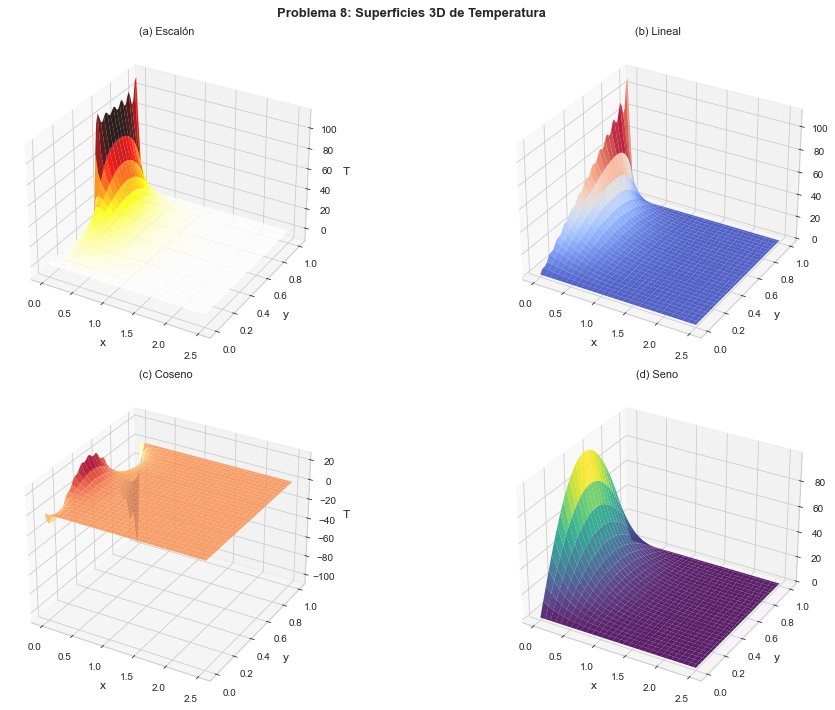

In [38]:
# Superficies 3D para las 4 condiciones
x8_3d = np.linspace(0, 2.5, 60)
y8_3d = np.linspace(0, b8, 60)
X8_3d, Y8_3d = np.meshgrid(x8_3d, y8_3d)

fig = plt.figure(figsize=(16, 10))
fig.suptitle('Problema 8: Superficies 3D de Temperatura', fontsize=13, fontweight='bold')

cmaps_3d = ['hot_r', 'coolwarm', 'RdYlBu_r', 'viridis']
for k, (case, cmap3d) in enumerate(zip(cases8, cmaps_3d)):
    ax3 = fig.add_subplot(2, 2, k+1, projection='3d')
    T8_3d = T8_gen(X8_3d, Y8_3d, An8[case])
    ax3.plot_surface(X8_3d, Y8_3d, T8_3d, cmap=cmap3d, alpha=0.88)
    name8 = {'step':'Escalón','linear':'Lineal','cosine':'Coseno','sine':'Seno'}[case]
    ax3.set_title(f'({"abcd"[k]}) {name8}', fontsize=11)
    ax3.set_xlabel('x', labelpad=3); ax3.set_ylabel('y', labelpad=3); ax3.set_zlabel('T', labelpad=3)

plt.tight_layout()
plt.show()

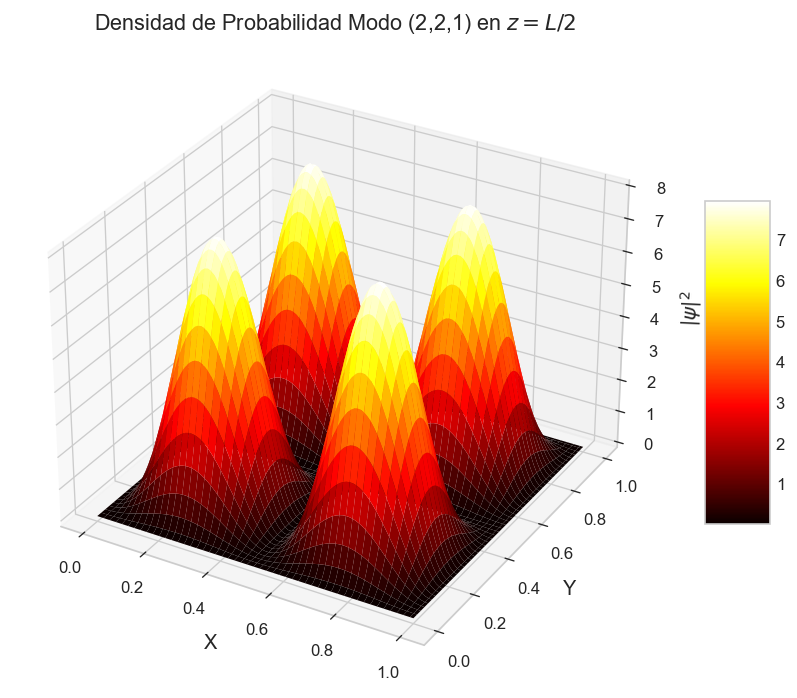

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# Configuración básica (basada en tu código)
L6 = 1.0
x6 = np.linspace(0, L6, 100)
y6 = np.linspace(0, L6, 100)
X6, Y6 = np.meshgrid(x6, y6)
z_mid = L6/2.0

# Selección de un modo específico, por ejemplo (2, 2, 1)
l, n, p = 2, 2, 1

# Cálculo de la densidad de probabilidad
psi2 = (np.sin(l*np.pi*X6/L6)*np.sin(n*np.pi*Y6/L6)*np.sin(p*np.pi*z_mid/L6))**2
psi2 *= 8/L6**3

# Crear la figura 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Graficar la superficie
surf = ax.plot_surface(X6, Y6, psi2, cmap='hot', edgecolor='none')

ax.set_title(f'Densidad de Probabilidad Modo ({l},{n},{p}) en $z=L/2$')
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('$|\\psi|^2$')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
plt.show()